# Commentary Evaluation Pipeline (LLM-as-a-Judge)

**Two stages:**
1. **Generation** — Generate NL move commentary (with or without engine info)
2. **Evaluation** — Tool-augmented atom-level judge:
   - **Decompose** candidate into atomic claims
   - **Verify** each atom against the board (tool-augmented)
   - **Match** candidate atoms to gold atoms
   - **Quality check** — does the explanation correctly assess move quality?

**Inputs:** `data/review_accepted.jsonl` (gold atoms), `data/review_demo.jsonl` (few-shot demos)

**Metrics:** Factual Precision, Recall (gold coverage), Quality correctness

---
## Setup & Data Loading

In [86]:
import json
import os
import math
import random
import numpy as np
import chess
import chess.engine
import chess.svg
from IPython.display import display, SVG, Markdown, HTML
from dotenv import load_dotenv
from dataclasses import dataclass

load_dotenv()

STOCKFISH_PATH = '/opt/homebrew/bin/stockfish'
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('')), 'evaluation', 'data', 'logical_chess_atomize')

K = 0.00368208


def cp_to_winpct(cp):
    """Lichess win% formula."""
    return 50 + 50 * math.tanh(K * cp / 2)


def get_engine_analysis(fen, move_uci=None, depth=22, multipv=3):
    """Get Stockfish top lines. If move_uci given and not in top-N, fetch separately."""
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        result = engine.analyse(board, chess.engine.Limit(depth=depth), multipv=multipv)
        lines = []
        for info in result:
            score = info['score'].white()
            pv = info.get('pv', [])
            if pv:
                b = board.copy()
                san_moves = []
                for m in pv[:8]:
                    san_moves.append(b.san(m))
                    b.push(m)
                cp = score.score(mate_score=10000)
                mate = score.mate()
                eval_str = f'M{mate}' if mate is not None else f'{cp/100:+.2f}'
                lines.append({
                    'move_uci': pv[0].uci(), 'move_san': board.san(pv[0]),
                    'eval': eval_str, 'pv_san': ' '.join(san_moves),
                    'cp': cp, 'mate': mate, 'is_top': True,
                })

        if move_uci is not None:
            if not any(l['move_uci'] == move_uci for l in lines):
                move_obj = chess.Move.from_uci(move_uci)
                move_san = board.san(move_obj)
                b2 = board.copy()
                b2.push(move_obj)
                info2 = engine.analyse(b2, chess.engine.Limit(depth=depth))
                sc2 = info2['score'].white()
                cp2 = sc2.score(mate_score=10000)
                mate2 = sc2.mate()
                eval2 = f'M{mate2}' if mate2 is not None else f'{cp2/100:+.2f}'
                pv2 = info2.get('pv', [])
                pv_sans = [move_san]
                b3 = b2.copy()
                for m in pv2[:7]:
                    pv_sans.append(b3.san(m))
                    b3.push(m)
                lines.append({
                    'move_uci': move_uci, 'move_san': move_san,
                    'eval': eval2, 'pv_san': ' '.join(pv_sans),
                    'cp': cp2, 'mate': mate2, 'is_top': False,
                })

    return lines


print(f'Data dir: {DATA_DIR}')

Data dir: /Users/ashwin/Documents/Princeton/chess/chess_annotation/evaluation/data/logical_chess_atomize


In [87]:
ACCEPTED_PATH = os.path.join(DATA_DIR, 'test_accepted.jsonl')
DEMO_PATH = os.path.join(DATA_DIR, 'review_demo.jsonl')

with open(ACCEPTED_PATH) as f:
    accepted_positions = [json.loads(line) for line in f]

with open(DEMO_PATH) as f:
    review_demos = [json.loads(line) for line in f]

# Raw entries for find_entry()
# with open(os.path.join(DATA_DIR, 'logical_chess_optimal_move.jsonl')) as f:
#     optimal_moves = [json.loads(line) for line in f]
# with open(os.path.join(DATA_DIR, 'logical_chess_other_move.jsonl')) as f:
#     other_moves = [json.loads(line) for line in f]
# _all_raw = optimal_moves + other_moves

# def find_entry(fen, move_uci):
#     for e in _all_raw:
#         if e['fen'] == fen and e['move_uci'] == move_uci:
#             return e
#     raise ValueError(f'Not found: {fen} {move_uci}')

print(f'Accepted positions: {len(accepted_positions)}')
print(f'Demo positions: {len(review_demos)}')
# print(f'Raw entries: {len(_all_raw)}')

Accepted positions: 54
Demo positions: 5


---
## Chess Tools & API Abstraction

In [88]:
import json as _json

def tool_get_legal_moves(fen):
    board = chess.Board(fen)
    moves = [board.san(m) for m in board.legal_moves]
    return _json.dumps({"moves": moves, "count": len(moves)})

def tool_get_piece_at(fen, square):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"square": square, "piece": "empty"})
    color = "white" if p.color == chess.WHITE else "black"
    return _json.dumps({"square": square, "piece": f"{color} {chess.piece_name(p.piece_type)}"})

def tool_get_attacks(fen, square):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"error": f"no piece on {square}"})
    attacks = sorted([chess.square_name(a) for a in board.attacks(sq)])
    return _json.dumps({"piece": p.symbol(), "square": square, "attacks": attacks})

def tool_get_attackers(fen, square, color):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    c = chess.WHITE if color == "white" else chess.BLACK
    attackers = [[chess.piece_name(board.piece_at(a).piece_type), chess.square_name(a)]
                 for a in board.attackers(c, sq)]
    return _json.dumps({"square": square, "color": color, "attackers": attackers})

def tool_count_attackers_defenders(fen, square):
    """Count attackers and defenders of a square for both colors."""
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    piece = board.piece_at(sq)
    
    white_attackers = [[chess.piece_name(board.piece_at(a).piece_type), 
                        chess.square_name(a)]
                       for a in board.attackers(chess.WHITE, sq)]
    black_attackers = [[chess.piece_name(board.piece_at(a).piece_type), 
                        chess.square_name(a)]
                       for a in board.attackers(chess.BLACK, sq)]
    
    result = {
        "square": square,
        "occupant": f"{('white' if piece.color == chess.WHITE else 'black')} {chess.piece_name(piece.piece_type)}" if piece else "empty",
        "white_attackers": {"count": len(white_attackers), "pieces": white_attackers},
        "black_attackers": {"count": len(black_attackers), "pieces": black_attackers},
    }
    
    if piece:
        if piece.color == chess.WHITE:
            result["defenders"] = {"count": len(white_attackers), "pieces": white_attackers}
            result["attackers"] = {"count": len(black_attackers), "pieces": black_attackers}
        else:
            result["defenders"] = {"count": len(black_attackers), "pieces": black_attackers}
            result["attackers"] = {"count": len(white_attackers), "pieces": white_attackers}
    
    return _json.dumps(result)

def tool_check_ray_alignment(square_a, square_b):
    """Check if two squares are aligned on a ray (rank/file/diagonal)."""
    sq_a = chess.parse_square(square_a)
    sq_b = chess.parse_square(square_b)
    
    result = {"square_a": square_a, "square_b": square_b, "aligned": False}
    
    if sq_a == sq_b:
        result["aligned"] = True
        result["ray_type"] = "same_square"
        return _json.dumps(result)
    
    if chess.square_rank(sq_a) == chess.square_rank(sq_b):
        result["aligned"] = True
        result["ray_type"] = "rank"
        result["rank"] = chess.square_rank(sq_a)
        return _json.dumps(result)
    
    if chess.square_file(sq_a) == chess.square_file(sq_b):
        result["aligned"] = True
        result["ray_type"] = "file"
        result["file"] = chess.file_name(chess.square_file(sq_a))
        return _json.dumps(result)
    
    if abs(chess.square_file(sq_a) - chess.square_file(sq_b)) == \
       abs(chess.square_rank(sq_a) - chess.square_rank(sq_b)):
        result["aligned"] = True
        result["ray_type"] = "diagonal"
        return _json.dumps(result)
    
    return _json.dumps(result)

def tool_is_pinned(fen, square):
    """Check if a piece is pinned. Returns pinner and pinned-to piece details."""
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"error": f"no piece on {square}"})
    pinned = board.is_pinned(p.color, sq)
    result = {"square": square, "pinned": pinned}
    if pinned:
        pin_mask = board.pin(p.color, sq)
        pin_squares = [chess.square_name(s) for s in chess.SquareSet(pin_mask)]
        result["pin_ray"] = pin_squares

        pinner = None
        pinned_to = None
        for s in chess.SquareSet(pin_mask):
            sq_name = chess.square_name(s)
            piece = board.piece_at(s)
            if piece and s != sq:
                if piece.color != p.color:
                    pinner = {"square": sq_name, "piece": f"{chess.piece_name(piece.piece_type)}"}
                else:
                    pinned_to = {"square": sq_name, "piece": f"{chess.piece_name(piece.piece_type)}"}

        if pinner:
            result["pinner"] = pinner
        if pinned_to:
            result["pinned_to"] = pinned_to
    return _json.dumps(result)

def tool_is_check(fen):
    board = chess.Board(fen)
    in_check = board.is_check()
    result = {"in_check": in_check}
    if in_check:
        result["checkers"] = [chess.square_name(sq) for sq in board.checkers()]
    return _json.dumps(result)

def tool_try_variation(fen, moves):
    board = chess.Board(fen)
    played = []
    for san in moves:
        try:
            move = board.parse_san(san)
            played.append(board.san(move))
            board.push(move)
        except Exception as e:
            return _json.dumps({"legal": False, "error": f"{san}: {str(e)}", "played": played})
    result = {"legal": True, "played": played, "resulting_fen": board.fen()}
    if board.is_checkmate():
        result["eval"] = "checkmate"
    elif board.is_stalemate():
        result["eval"] = "stalemate"
    else:
        with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
            info = engine.analyse(board, chess.engine.Limit(depth=18))
            sc = info['score'].white()
            mate = sc.mate()
            result["eval"] = f"M{mate}" if mate is not None else f"{sc.score(mate_score=10000)/100:+.2f}"
    return _json.dumps(result)

def tool_get_engine_eval(fen, depth=20):
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        info = engine.analyse(board, chess.engine.Limit(depth=int(depth)))
        sc = info['score'].white()
        pv = info.get('pv', [])
        mate = sc.mate()
        ev = f"M{mate}" if mate is not None else f"{sc.score(mate_score=10000)/100:+.2f}"
        best = board.san(pv[0]) if pv else "?"
    return _json.dumps({"eval": ev, "best_move": best})

def tool_get_top_moves(fen, n=3, depth=20):
    """Get top N engine moves with evals and PV lines."""
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        result = engine.analyse(board, chess.engine.Limit(depth=int(depth)), multipv=int(n))
        moves = []
        for info in result:
            score = info['score'].white()
            pv = info.get('pv', [])
            if pv:
                b = board.copy()
                san_moves = []
                for m in pv[:6]:
                    san_moves.append(b.san(m))
                    b.push(m)
                cp = score.score(mate_score=10000)
                mate = score.mate()
                ev = f"M{mate}" if mate is not None else f"{cp/100:+.2f}"
                moves.append({"move": board.san(pv[0]), "eval": ev, "pv": " ".join(san_moves)})
    return _json.dumps({"top_moves": moves})

def tool_eval_move(fen, move, depth=20):
    """Evaluate a specific move: eval, best move, wp_loss, quality."""
    board = chess.Board(fen)
    def wp(cp):
        return 50 + 50 * math.tanh(K * cp / 2)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        root_info = engine.analyse(board, chess.engine.Limit(depth=int(depth)))
        root_cp = root_info['score'].white().score(mate_score=10000)
        root_pv = root_info.get('pv', [])
        best_move_san = board.san(root_pv[0]) if root_pv else "?"

        m = board.parse_san(move)
        move_san = board.san(m)
        b2 = board.copy()
        b2.push(m)
        move_info = engine.analyse(b2, chess.engine.Limit(depth=int(depth)))
        move_cp = move_info['score'].white().score(mate_score=10000)
        move_mate = move_info['score'].white().mate()
        move_eval_str = f"M{move_mate}" if move_mate is not None else f"{move_cp/100:+.2f}"

    if board.turn == chess.WHITE:
        wp_loss_val = wp(root_cp) - wp(move_cp)
    else:
        wp_loss_val = wp(move_cp) - wp(root_cp)
    wp_loss_val = round(max(0, wp_loss_val), 1)
    quality = "good" if wp_loss_val < 5 else ("bad" if wp_loss_val < 20 else "blunder")

    return _json.dumps({
        "move": move_san, "move_eval": move_eval_str,
        "best_move": best_move_san, "wp_loss": wp_loss_val, "quality": quality,
    })

def tool_compare_moves(fen, move_a, move_b, depth=20):
    board = chess.Board(fen)
    def wp(cp):
        return 50 + 50 * math.tanh(K * cp / 2)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        ba = board.copy(); ba.push(board.parse_san(move_a))
        ia = engine.analyse(ba, chess.engine.Limit(depth=int(depth)))
        sa = ia['score'].white().score(mate_score=10000)
        bb = board.copy(); bb.push(board.parse_san(move_b))
        ib = engine.analyse(bb, chess.engine.Limit(depth=int(depth)))
        sb = ib['score'].white().score(mate_score=10000)
    return _json.dumps({
        "move_a": move_a, "eval_a": f"{sa/100:+.2f}",
        "move_b": move_b, "eval_b": f"{sb/100:+.2f}",
        "wp_diff": round(abs(wp(sa) - wp(sb)), 1)
    })

def tool_make_move(fen, move):
    board = chess.Board(fen)
    m = board.parse_san(move)
    gives_check = board.gives_check(m)
    board.push(m)
    return _json.dumps({"fen": board.fen(), "gives_check": gives_check})

_PIECE_NAMES = {"pawn": chess.PAWN, "knight": chess.KNIGHT, "bishop": chess.BISHOP,
                "rook": chess.ROOK, "queen": chess.QUEEN, "king": chess.KING}

def tool_get_squares(fen, piece, color=None):
    """Find all squares of a piece type, optionally by color."""
    board = chess.Board(fen)
    pt = _PIECE_NAMES.get(piece.lower())
    if pt is None:
        return _json.dumps({"error": f"unknown piece: {piece}"})
    colors = []
    if color is None:
        colors = [chess.WHITE, chess.BLACK]
    elif color == "white":
        colors = [chess.WHITE]
    elif color == "black":
        colors = [chess.BLACK]
    else:
        return _json.dumps({"error": f"unknown color: {color}"})
    results = []
    for c in colors:
        cname = "white" if c == chess.WHITE else "black"
        for sq in board.pieces(pt, c):
            results.append({"square": chess.square_name(sq), "color": cname})
    return _json.dumps({"piece": piece, "squares": results})

def tool_get_material(fen):
    """Get material count for both sides."""
    board = chess.Board(fen)
    result = {}
    for color_name, color in [("white", chess.WHITE), ("black", chess.BLACK)]:
        pieces = {}
        for pt, name in [(chess.PAWN, "pawns"), (chess.KNIGHT, "knights"),
                         (chess.BISHOP, "bishops"), (chess.ROOK, "rooks"),
                         (chess.QUEEN, "queens")]:
            count = len(board.pieces(pt, color))
            if count > 0:
                pieces[name] = count
        result[color_name] = pieces
    return _json.dumps(result)

def tool_compare_positions(fen_a, fen_b, depth=18):
    """Compare material counts and engine eval between two FENs."""
    _piece_vals = {chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3,
                   chess.ROOK: 5, chess.QUEEN: 9}

    def _mat(board, color):
        return sum(len(board.pieces(pt, color)) * v for pt, v in _piece_vals.items())

    board_a = chess.Board(fen_a)
    board_b = chess.Board(fen_b)

    w_a, b_a = _mat(board_a, chess.WHITE), _mat(board_a, chess.BLACK)
    w_b, b_b = _mat(board_b, chess.WHITE), _mat(board_b, chess.BLACK)

    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        info_a = engine.analyse(board_a, chess.engine.Limit(depth=int(depth)))
        sc_a = info_a['score'].white().score(mate_score=10000)
        info_b = engine.analyse(board_b, chess.engine.Limit(depth=int(depth)))
        sc_b = info_b['score'].white().score(mate_score=10000)

    return _json.dumps({
        "position_a": {"white_material": w_a, "black_material": b_a,
                        "eval": f"{sc_a/100:+.2f}"},
        "position_b": {"white_material": w_b, "black_material": b_b,
                        "eval": f"{sc_b/100:+.2f}"},
        "material_change": {"white": w_b - w_a, "black": b_b - b_a},
        "eval_change": f"{(sc_b - sc_a)/100:+.2f}",
    })


TOOL_FUNCTIONS = {
    "get_legal_moves": tool_get_legal_moves, "get_piece_at": tool_get_piece_at,
    "get_attacks": tool_get_attacks, "get_attackers": tool_get_attackers,
    "count_attackers_defenders": tool_count_attackers_defenders,
    "check_ray_alignment": tool_check_ray_alignment,
    "is_pinned": tool_is_pinned, "is_check": tool_is_check,
    "try_variation": tool_try_variation, "get_engine_eval": tool_get_engine_eval,
    "get_top_moves": tool_get_top_moves, "eval_move": tool_eval_move,
    "compare_moves": tool_compare_moves, "make_move": tool_make_move,
    "get_squares": tool_get_squares, "get_material": tool_get_material,
    "compare_positions": tool_compare_positions,
}

def _schema(name, desc, props, required):
    return {"type": "function", "function": {"name": name, "description": desc,
            "parameters": {"type": "object", "properties": props, "required": required}}}

_fen_prop = {"fen": {"type": "string", "description": "FEN of the position"}}
_sq_prop = {"square": {"type": "string", "description": "Square name, e.g. 'd3'"}}

TOOL_SCHEMAS_OPENAI = [
    _schema("get_legal_moves", "Get all legal moves in SAN.", _fen_prop, ["fen"]),
    _schema("get_piece_at", "Get the piece on a square.", {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("get_attacks", "Get squares attacked by piece on a square.", {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("get_attackers", "Get pieces of a color attacking a square.",
            {**_fen_prop, **_sq_prop, "color": {"type": "string", "enum": ["white", "black"]}},
            ["fen", "square", "color"]),
    _schema("count_attackers_defenders", "Count attackers and defenders of a square (both colors). Use this to verify 'removes a defender' or 'adds an attacker' claims.",
            {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("check_ray_alignment", "Check if two squares are on the same rank/file/diagonal. Use to verify 'on the same diagonal', 'in line with' claims.",
            {"square_a": {"type": "string"}, "square_b": {"type": "string"}}, ["square_a", "square_b"]),
    _schema("is_pinned", "Check if a piece is pinned. Returns the pinner (attacking piece) and pinned-to piece (protected piece, usually king/queen).", {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("is_check", "Check if side to move is in check.", _fen_prop, ["fen"]),
    _schema("try_variation", "Try a sequence of SAN moves. Returns resulting FEN.",
            {**_fen_prop, "moves": {"type": "array", "items": {"type": "string"}}}, ["fen", "moves"]),
    _schema("get_engine_eval", "Get Stockfish eval + best move.",
            {**_fen_prop, "depth": {"type": "integer"}}, ["fen"]),
    _schema("get_top_moves", "Get top N engine moves with evals and PV lines.",
            {**_fen_prop, "n": {"type": "integer"}, "depth": {"type": "integer"}}, ["fen"]),
    _schema("eval_move", "Evaluate a specific move: eval, best move, wp_loss, quality.",
            {**_fen_prop, "move": {"type": "string"}, "depth": {"type": "integer"}}, ["fen", "move"]),
    _schema("compare_moves", "Compare eval of two moves.",
            {**_fen_prop, "move_a": {"type": "string"}, "move_b": {"type": "string"},
             "depth": {"type": "integer"}}, ["fen", "move_a", "move_b"]),
    _schema("compare_positions", "Compare material and eval between two positions.",
            {"fen_a": {"type": "string", "description": "FEN of position A"},
             "fen_b": {"type": "string", "description": "FEN of position B"},
             "depth": {"type": "integer", "description": "Engine depth (default 18)"}},
            ["fen_a", "fen_b"]),
    _schema("make_move", "Make a move, return new FEN.",
            {**_fen_prop, "move": {"type": "string"}}, ["fen", "move"]),
    _schema("get_squares", "Find all squares of a piece type, optionally by color. Use when square not specified (e.g., 'a knight is pinned').",
            {**_fen_prop, "piece": {"type": "string", "enum": ["pawn","knight","bishop","rook","queen","king"]},
             "color": {"type": "string", "enum": ["white", "black"]}}, ["fen", "piece"]),
    _schema("get_material", "Get material count for both sides.", _fen_prop, ["fen"]),
]

TOOL_SCHEMAS_ANTHROPIC = [
    {"name": s["function"]["name"], "description": s["function"]["description"],
     "input_schema": s["function"]["parameters"]} for s in TOOL_SCHEMAS_OPENAI
]

def execute_tool(name, arguments):
    fn = TOOL_FUNCTIONS.get(name)
    if fn is None:
        return _json.dumps({"error": f"unknown tool: {name}"})
    try:
        return fn(**arguments)
    except Exception as e:
        return _json.dumps({"error": str(e)})

print(f'Tools: {list(TOOL_FUNCTIONS.keys())}')

Tools: ['get_legal_moves', 'get_piece_at', 'get_attacks', 'get_attackers', 'count_attackers_defenders', 'check_ray_alignment', 'is_pinned', 'is_check', 'try_variation', 'get_engine_eval', 'get_top_moves', 'eval_move', 'compare_moves', 'make_move', 'get_squares', 'get_material', 'compare_positions']


In [89]:
# ── API Abstraction ───────────────────────────────────────────────────────

@dataclass
class ToolCall:
    id: str
    name: str
    arguments: dict

@dataclass
class LLMResponse:
    text: str
    tool_calls: list


def call_openai(messages, tools=None, model="gpt-4o", temperature=0.3):
    import openai
    client = openai.OpenAI()
    token_key = "max_completion_tokens" if any(m in model for m in ("gpt-4.1", "gpt-5", "o3", "o4")) else "max_tokens"
    kwargs = dict(model=model, messages=messages, temperature=temperature, **{token_key: 2048})
    if tools:
        kwargs["tools"] = tools
        kwargs["tool_choice"] = "auto"
    resp = client.chat.completions.create(**kwargs)
    msg = resp.choices[0].message
    text = msg.content or ""
    tc = []
    if msg.tool_calls:
        for c in msg.tool_calls:
            tc.append(ToolCall(id=c.id, name=c.function.name,
                               arguments=_json.loads(c.function.arguments)))
    return LLMResponse(text=text, tool_calls=tc), msg


def call_anthropic(messages, tools=None, model="claude-sonnet-4-5-20250929",
                   system=None, temperature=0.3):
    import anthropic
    client = anthropic.Anthropic()
    kwargs = dict(model=model, max_tokens=2048, temperature=temperature)
    if system:
        kwargs["system"] = system
    api_messages = [m for m in messages if m["role"] != "system"]
    kwargs["messages"] = api_messages
    if tools:
        kwargs["tools"] = tools
    resp = client.messages.create(**kwargs)
    text = ""
    tc = []
    for block in resp.content:
        if block.type == "text":
            text += block.text
        elif block.type == "tool_use":
            tc.append(ToolCall(id=block.id, name=block.name, arguments=block.input))
    return LLMResponse(text=text, tool_calls=tc), resp


def call_llm(messages, tools=None, provider="openai", model=None, temperature=0.3):
    if provider == "openai":
        return call_openai(messages, tools=tools, model=model or "gpt-4o", temperature=temperature)
    elif provider == "anthropic":
        m = model or "claude-sonnet-4-5-20250929"
        sys_msg = next((msg["content"] for msg in messages if msg["role"] == "system"), None)
        return call_anthropic(messages, tools=tools, model=m, system=sys_msg, temperature=temperature)
    else:
        raise ValueError(f"Unknown provider: {provider}")


PROVIDER = "openai"
MODEL = "gpt-4o"
MAX_TOOL_ROUNDS = 10


def _call_with_tools(messages, provider=PROVIDER, model=MODEL, temperature=0.3,
                     max_rounds=MAX_TOOL_ROUNDS, verbose=True):
    """Run LLM with tool access, handling multi-round tool calls.
    Returns (final_text, tool_log)."""
    tool_schemas = TOOL_SCHEMAS_OPENAI if provider == "openai" else TOOL_SCHEMAS_ANTHROPIC
    tool_log = []

    for _ in range(max_rounds):
        resp, raw = call_llm(messages, tools=tool_schemas, provider=provider,
                             model=model, temperature=temperature)

        if not resp.tool_calls:
            return resp.text.strip() if resp.text else "", tool_log

        if provider == "openai":
            messages.append({
                "role": "assistant", "content": resp.text or None,
                "tool_calls": [{"id": tc.id, "type": "function",
                                "function": {"name": tc.name,
                                             "arguments": _json.dumps(tc.arguments)}}
                               for tc in resp.tool_calls],
            })
            for tc in resp.tool_calls:
                result = execute_tool(tc.name, tc.arguments)
                tool_log.append({"tool": tc.name, "args": tc.arguments, "result": result})
                if verbose:
                    print(f"    tool: {tc.name}({tc.arguments}) -> {result[:80]}")
                messages.append({"role": "tool", "tool_call_id": tc.id, "content": result})
        elif provider == "anthropic":
            content_blocks = []
            if resp.text:
                content_blocks.append({"type": "text", "text": resp.text})
            for tc in resp.tool_calls:
                content_blocks.append({"type": "tool_use", "id": tc.id,
                                       "name": tc.name, "input": tc.arguments})
            messages.append({"role": "assistant", "content": content_blocks})
            tool_results = []
            for tc in resp.tool_calls:
                result = execute_tool(tc.name, tc.arguments)
                tool_log.append({"tool": tc.name, "args": tc.arguments, "result": result})
                if verbose:
                    print(f"    tool: {tc.name}({tc.arguments}) -> {result[:80]}")
                tool_results.append({"type": "tool_result", "tool_use_id": tc.id,
                                     "content": result})
            messages.append({"role": "user", "content": tool_results})

    return resp.text.strip() if resp.text else "[max tool rounds]", tool_log


print(f'API ready. Provider: {PROVIDER}, Model: {MODEL}')

API ready. Provider: openai, Model: gpt-4o


---
## Generation Template

In [90]:
GEN_SYSTEM_PROMPT = """\
You are a chess instructor explaining moves to an intermediate player.

Given a position (FEN), the move played, and engine analysis, write a concise, \
instructive explanation of the move.

GUIDELINES:
- Explain the strategic or tactical purpose of the move.
- If the move is bad or a blunder: explain why it fails and what was better.
- Be specific: name squares, pieces, diagonals, and key variations.
- No generic chess philosophy or filler. Every sentence must be position-specific.
- Keep it concise. A simple forced move needs one sentence. \
A rich tactical position deserves a short paragraph.
- Output plain text only. No JSON, no bullet points, no headers."""

GEN_RAW_SYSTEM_PROMPT = """\
You are a chess instructor explaining moves to an intermediate player.

Given a position (FEN) and the move played, write a concise, instructive \
explanation of the move. You have access to chess analysis tools \u2014 use them \
to understand the position before writing your explanation.

GUIDELINES:
- Explain the strategic or tactical purpose of the move.
- If the move is bad or a blunder: explain why it fails and what was better.
- Be specific: name squares, pieces, diagonals, and key variations.
- No generic chess philosophy or filler. Every sentence must be position-specific.
- Keep it concise. A simple forced move needs one sentence. \
A rich tactical position deserves a short paragraph.
- Output plain text only. No JSON, no bullet points, no headers."""


def fen_to_ascii(fen):
    return str(chess.Board(fen))


def build_gen_user_prompt(entry, engine_lines, ascii=False):
    """Build user prompt: FEN + move + engine (NO commentary)."""
    board = chess.Board(entry['fen'])
    move_san = board.san(chess.Move.from_uci(entry['move_uci']))

    top_lines = [l for l in engine_lines if l.get('is_top', True)]
    played_line = next((l for l in engine_lines if not l.get('is_top', True)), None)

    pv_text = []
    for i, line in enumerate(top_lines, 1):
        pv_text.append(f"  {i}. {line['move_san']} ({line['eval']}): {line['pv_san']}")

    wp_loss = entry.get('wp_loss', 0)
    if wp_loss > 20:   quality_hint = f" [BLUNDER \u2014 wp_loss: {wp_loss:.1f}%]"
    elif wp_loss > 5:  quality_hint = f" [SUBOPTIMAL \u2014 wp_loss: {wp_loss:.1f}%]"
    else:              quality_hint = f" [wp_loss: {wp_loss:.1f}%]"

    prompt = f"FEN: {entry['fen']}\n"
    if ascii:
        prompt += f"Board:\n{fen_to_ascii(entry['fen'])}\n"
    prompt += f"Move played: {move_san}{quality_hint}\nEngine top-3:\n" + "\n".join(pv_text) + "\n"
    if played_line:
        prompt += f"Played move eval:\n  {played_line['move_san']} ({played_line['eval']}): {played_line['pv_san']}\n"
    return prompt


def build_gen_user_prompt_raw(entry, ascii=False):
    """Build user prompt: FEN + move only (no engine lines)."""
    board = chess.Board(entry['fen'])
    move_san = board.san(chess.Move.from_uci(entry['move_uci']))
    prompt = f"FEN: {entry['fen']}\n"
    if ascii:
        prompt += f"Board:\n{fen_to_ascii(entry['fen'])}\n"
    prompt += f"Move played: {move_san}\n"
    return prompt


# Build demo messages
print("Building generation demos...")

GEN_DEMOS = []
GEN_RAW_DEMOS = []

for demo in review_demos:
    entry = {'fen': demo['fen'], 'move_uci': demo['move_uci'],
             'wp_loss': demo.get('wp_loss', 0)}
    el = demo.get('engine_lines') or get_engine_analysis(demo['fen'], demo['move_uci'])
    user_prompt = build_gen_user_prompt(entry, el)
    GEN_DEMOS.append({"role": "user", "content": user_prompt})
    GEN_DEMOS.append({"role": "assistant", "content": demo['demo_output']})

    raw_prompt = build_gen_user_prompt_raw(entry)
    GEN_RAW_DEMOS.append({"role": "user", "content": raw_prompt})
    GEN_RAW_DEMOS.append({"role": "assistant", "content": demo['demo_output']})

    board = chess.Board(demo['fen'])
    san = board.san(chess.Move.from_uci(demo['move_uci']))
    print(f"  {san} ({demo.get('quality', '?')}): done")

print(f"\nGeneration template ready: {len(GEN_DEMOS)//2} demos")

Building generation demos...
  Nxd7 (good): done
  Qe5 (good): done
  Bxd4 (good): done
  exd4 (bad): done
  O-O (mistake): done

Generation template ready: 5 demos


In [91]:
def generate_commentary(entry, engine_lines, provider=PROVIDER, model=MODEL, ascii=False):
    """Generate NL move commentary with engine info. Returns (text, tool_log)."""
    messages = [{"role": "system", "content": GEN_SYSTEM_PROMPT}]
    messages.extend(GEN_DEMOS)
    messages.append({"role": "user", "content": build_gen_user_prompt(entry, engine_lines, ascii=ascii)})
    return _call_with_tools(messages, provider=provider, model=model, temperature=0.3)


def generate_commentary_raw(entry, provider=PROVIDER, model=MODEL, ascii=False):
    """Generate commentary from FEN + move only (tool-augmented). Returns (text, tool_log)."""
    messages = [{"role": "system", "content": GEN_RAW_SYSTEM_PROMPT}]
    messages.extend(GEN_RAW_DEMOS)
    messages.append({"role": "user", "content": build_gen_user_prompt_raw(entry, ascii=ascii)})
    return _call_with_tools(messages, provider=provider, model=model, temperature=0.3)


print('Generation functions ready.')

Generation functions ready.


---
## LLM-as-Judge (Improved)

Tool-augmented **per-atom** evaluation:
1. **Decompose** candidate explanation into atomic claims
2. **Verify** each atom individually (fresh tool conversation + sanity checks)
3. **Match** candidate atoms to gold atoms
4. **Quality check** — does the explanation correctly assess move quality?
5. **Score** fluency, specificity, composite

In [92]:
import re


def _parse_judge_json(text):
    """Parse JSON from judge LLM output, handling markdown fences."""
    text = text.strip()
    if text.startswith('```'):
        text = text.split('\n', 1)[1]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        print(f"  [JSON parse error] {text[:200]}...")
        return {}


# ── Step 1: Decompose ─────────────────────────────────────────────────────

DECOMPOSE_SYSTEM = """\
Extract atomic factual claims from a chess move explanation.

CRITICAL: ONE CLAIM PER ATOM. Each atom must contain exactly ONE verifiable fact. \
If a sentence contains multiple claims, split it into separate atoms.

EXAMPLE — given this text:
"Bf3 allows Black to play Bf5, skewering the queen on b1 and the knight on c3."

BAD (compound claims):
- "Bf3 allows Black to play Bf5, skewering the queen on b1 and the knight on c3."

GOOD (atomic claims - one fact each):
- "Bf3 would allow Black to play Bf5"
- "After Bf3 Bf5, the white queen is on b1"
- "After Bf3 Bf5, there is a white knight on c3"
- "After Bf3 Bf5, the bishop on f5 skewers the queen on b1 and knight on c3"

CONTEXTUAL ATOMS: Each atom must be self-contained with full positional context. \
If an atom references a position after a sequence of moves, include the FULL \
preceding move sequence.

EXAMPLE — given this text:
"Nxd7 removes one of the defenders of the knight on f6. After the expected Nh5, \
White can capture the bishop on g6."

BAD (later atoms lose context):
- "Nxd7 removes one of the defenders of the knight on f6."
- "After Nh5, White can capture the bishop on g6."  <- Nh5 from where?

GOOD (each carries full move sequence from root):
- "Nxd7 removes one of the defenders of the knight on f6."
- "After Nxd7 Nh5, White can capture the bishop on g6."

EXAMPLE 2 — given text about alternative moves:
"Instead, White should play Nd5, attacking the bishop and threatening Nxf6, which would disrupt Black's pawn structure."

BAD (loses context of the alternative move):
- "Nd5 attacks the bishop."
- "Nxf6 would disrupt Black's pawn structure."  <- From where? After which moves?

GOOD (includes full context):
- "If White plays Nd5 instead, the knight would attack the bishop on e7."
- "After Nd5 Nxf6, Black's pawn structure would be disrupted."

CRITICAL: For consequences of move sequences, ALWAYS include the complete sequence.

RULES:
1. ONE claim per atom - split compound claims into separate atoms
2. Be specific — include piece names, squares, and concrete assertions
3. Group logically connected setup+consequence ONLY if they're inseparable
4. Each atom must include the FULL move sequence from the root position
5. Ignore stylistic flourishes that make no factual claim
6. Ignore generic chess philosophy not applied to this position

Output valid JSON with claims grouped by logical assertions:
{
  "claims": [
    {
      "claim_text": "Complete sentence(s) making this assertion",
      "atoms": [
        "Atomic fact 1",
        "Atomic fact 2",
        "Atomic fact 3"
      ]
    },
    {
      "claim_text": "Another logical assertion",
      "atoms": ["Atomic fact 4"]
    }
  ]
}

EXAMPLE OUTPUT:
{
  "claims": [
    {
      "claim_text": "Bf3 is a blunder because it allows Black to play Bf5, skewering the queen on b1 and the rook on d1.",
      "atoms": [
        "Bf3 is a blunder",
        "Bf3 allows Black to play Bf5",
        "After Bf3 Bf5, the white queen is on b1",
        "After Bf3 Bf5, the white rook is on d1",
        "After Bf3 Bf5, the bishop on f5 skewers the queen on b1 and rook on d1"
      ]
    },
    {
      "claim_text": "Instead, White should have played Nd5, attacking the bishop on e7.",
      "atoms": [
        "If White plays Nd5 instead, the knight would attack the bishop on e7"
      ]
    }
  ]
}"""


def decompose_to_atoms(text, provider=PROVIDER, model=MODEL):
    """Decompose NL explanation into claims and atoms.
    
    Returns: (atoms_list, claims_list)
    where claims_list = [
        {'claim_text': '...', 'atom_indices': [0, 1, 2], 'atoms': [...]},
        ...
    ]
    """
    messages = [
        {"role": "system", "content": DECOMPOSE_SYSTEM},
        {"role": "user", "content": text},
    ]
    resp, _ = call_llm(messages, provider=provider, model=model, temperature=0.0)
    data = _parse_judge_json(resp.text)
    
    # Flatten atoms and build claims structure
    atoms = []
    claims = []
    
    for claim_data in data.get('claims', []):
        claim_atoms = claim_data.get('atoms', [])
        start_idx = len(atoms)
        atoms.extend(claim_atoms)
        end_idx = len(atoms)
        
        claims.append({
            'claim_text': claim_data.get('claim_text', ''),
            'atom_indices': list(range(start_idx, end_idx)),
            'atoms': claim_atoms,  # Keep for reference
        })
    
    # Fallback: if no claims structure, treat each atom as a separate claim
    if not claims and 'atoms' in data:
        atoms = data['atoms']
        claims = [
            {'claim_text': atom, 'atom_indices': [i], 'atoms': [atom]}
            for i, atom in enumerate(atoms)
        ]
    
    return atoms, claims


# ── Step 2a: Classify atoms ───────────────────────────────────────────────

def classify_atom(atom_text):
    """Regex-based classification of an atom into semantic types."""
    text = atom_text.lower()
    types = []

    if re.search(r'\b(good|bad|blunder|mistake|inaccuracy|dubious|best move|excellent|strong move|weak move|poor|brilliant)\b', text):
        types.append('quality')

    if re.search(r'\b(better|worse|instead|rather than|compared to|alternative|superior|inferior|preferable)\b', text):
        types.append('comparison')

    if re.search(r'\b(wins?\s+(material|a?\s*piece|a?\s*pawn|the exchange)|sacrifice|captures?|takes|recapture|material\s+(advantage|gain|loss))\b', text):
        types.append('material')

    if re.search(r'\b(after\s+\S+\s+\S+|variation|line|sequence|follows|continuation)\b', text) or text.count('...') > 0:
        types.append('move_sequence')

    if re.search(r'\b(fork|pins?|skewer|discovered|double attack|back rank|mate|checkmate|trap|tactic|combination)\b', text):
        types.append('tactic')

    if re.search(r'\b(outpost|weak square|pawn structure|open file|diagonal|fianchetto|isolated|doubled|passed|backward|space|control|center|centre)\b', text):
        types.append('positional')

    if re.search(r'\b(on\s+[a-h][1-8]|to\s+[a-h][1-8]|places|develops|moves?\s+to|lands?\s+on|from\s+[a-h][1-8])\b', text):
        types.append('piece_placement')

    if re.search(r'\b(threatens?|threatening|attacks?|targeting)\b', text):
        types.append('threat')

    if re.search(r'\b(defends?|defender|protects?|guards?|removes?\s.*defender|undefended|unprotected)\b', text):
        types.append('defender')

    if not types:
        types.append('general')

    return types


# ── Step 2b: Per-atom verification prompt ─────────────────────────────────

VERIFY_SINGLE_SYSTEM = """\
You are a chess fact-checker verifying a SINGLE atomic claim about a chess position.

POSITION CONTEXT:
- Pre-move FEN: {pre_fen}
- Move played: {move_san} (UCI: {move_uci})
- Post-move FEN: {post_fen}
- Side that played the move: {side_to_move}

CLAIM TO VERIFY:
{atom}

VERIFICATION RULES:

1. MANDATORY TOOL USE: A verdict without any tool call is INVALID. You MUST call \
at least one tool to verify this claim. Do not rely on your own chess analysis.

2. EVAL_MOVE INTERPRETATION: When using eval_move, the wp_loss value represents \
the win-percentage lost BY THE SIDE PLAYING THE MOVE, not the other side.
   - wp_loss < 5: good move
   - wp_loss 5-20: suboptimal/inaccuracy
   - wp_loss > 20: blunder

3. WHICH FEN TO USE:
   - Claims about the position AFTER the move -> use post-move FEN
   - Claims about what existed BEFORE the move -> use pre-move FEN
   - Claims about alternative moves -> use pre-move FEN
   - Variations from the post-move position -> use post-move FEN

4. For COMPARISON claims ("X is better than Y", "instead of Y"):
   You MUST evaluate BOTH moves. Use eval_move or compare_moves on both.

5. For VARIATION claims ("after X Y Z..."):
   Use try_variation to test the full sequence.

6. For PIECE PLACEMENT claims ("piece on X"):
   Use get_piece_at to verify.

7. For claims about ALTERNATIVE MOVES (e.g., "Nd5 attacks..." when discussing what White should have played instead):
   - The atom may reference pieces or positions that don't exist in pre/post-move FENs
   - First try playing the alternative move from pre-move FEN using try_variation
   - Then verify the claim in the resulting position
   - Check that the alternative move is legal before verifying its consequences

{type_specific_guidance}

OUTPUT: Respond with valid JSON only:
{{"verified": true/false, "confidence": "high"/"medium"/"low", "reasoning": "..."}}

Your reasoning MUST cite specific tool results."""


TYPE_GUIDANCE = {
    'quality': """\
QUALITY CHECK GUIDANCE:
- Use eval_move(pre_fen, move) to get wp_loss
- wp_loss < 5 = good, 5-20 = suboptimal, > 20 = blunder
- If the atom says "good move" but wp_loss > 15, it's WRONG
- If the atom says "blunder" but wp_loss < 10, it's WRONG""",

    'comparison': """\
COMPARISON CHECK GUIDANCE:
- You MUST evaluate BOTH moves being compared using eval_move or compare_moves
- Compare their wp_loss values to determine which is actually better
- Do NOT conclude one move is better without checking both""",

    'material': """\
MATERIAL CHECK GUIDANCE:
- Use get_material or get_piece_at to verify material claims
- For captures, compare material before and after using both FENs
- Use compare_positions to compare material between two positions""",

    'tactic': """\
TACTIC CHECK GUIDANCE:
- For pins: use is_pinned(fen, square)
- For forks: check get_attacks on the forking piece
- For skewers: use is_pinned (skewers show as pins on higher-value pieces)
- For discovered attacks: play the move with try_variation, then check attacks""",

    'piece_placement': """\
PIECE PLACEMENT GUIDANCE:
- Use get_piece_at(fen, square) to verify exact piece locations
- For "piece on [square]" claims, check the CORRECT fen (pre or post move)
- The UCI notation shows from->to: e.g. e2f3 means piece was on e2, now on f3
- If atom mentions a piece on a square that doesn't exist in pre/post FENs (e.g., "Nd5 attacks..." when no N on d5), it likely refers to an alternative move. Use try_variation to play that move from pre-move FEN, then verify in the result""",

    'threat': """\
THREAT CHECK GUIDANCE:
- Use try_variation to play the threatened move sequence
- Then verify the consequence in the resulting position
- Check if the threat is actually legal and effective""",

    'defender': """\
DEFENDER CHECK GUIDANCE:
- Use count_attackers_defenders on BOTH pre-move and post-move FENs
- Compare defender counts to verify "removes a defender" claims
- Check both the claimed square and the defending piece's square""",

    'positional': """\
POSITIONAL CHECK GUIDANCE:
- For diagonal/file claims: use check_ray_alignment or get_attacks
- For pawn structure: use get_squares(fen, "pawn", color)
- For control claims: use get_attacks or count_attackers_defenders""",

    'move_sequence': """\
MOVE SEQUENCE GUIDANCE:
- Use try_variation with the FULL move sequence
- Check that all moves are legal
- Verify the claimed consequence in the resulting position""",
}


# ── Step 2c: Single-atom verification ─────────────────────────────────────

def verify_single_atom(atom, fen, move_san, move_uci,
                       provider=PROVIDER, model=MODEL, verbose=True):
    """Verify a single atom with a fresh tool-calling conversation.
    Returns dict with atom, verified, confidence, reasoning, tool_log, etc."""
    board = chess.Board(fen)
    side_to_move = "White" if board.turn == chess.WHITE else "Black"
    board.push(chess.Move.from_uci(move_uci))
    post_fen = board.fen()

    atom_types = classify_atom(atom)

    # Build type-specific guidance
    guidance_parts = []
    for t in atom_types:
        if t in TYPE_GUIDANCE:
            guidance_parts.append(TYPE_GUIDANCE[t])
    type_guidance = "\n\n".join(guidance_parts) if guidance_parts else ""

    system_msg = VERIFY_SINGLE_SYSTEM.format(
        pre_fen=fen, post_fen=post_fen,
        move_san=move_san, move_uci=move_uci,
        side_to_move=side_to_move, atom=atom,
        type_specific_guidance=type_guidance,
    )

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": f"Verify this claim: {atom}"},
    ]

    if verbose:
        print(f"    Verifying: {atom[:80]}...")

    text, tool_log = _call_with_tools(
        messages, provider=provider, model=model,
        temperature=0.0, max_rounds=10, verbose=verbose)

    data = _parse_judge_json(text)

    return {
        'atom': atom,
        'verified': data.get('verified', False),
        'confidence': data.get('confidence', 'low'),
        'reasoning': data.get('reasoning', text),
        'atom_types': atom_types,
        'tool_log': tool_log,
        'tool_summary': [{'tool': t['tool'], 'args': t['args']} for t in tool_log],
    }


# ── Step 2d: Sanity checks ───────────────────────────────────────────────

def run_sanity_checks(verify_result, fen, move_uci, is_alternative_atom=False):
    """Programmatic post-hoc checks on a verified atom. Can override LLM verdict.

    Checks:
    1. No tool calls -> force verified=False
    2. Quality wp_loss consistency
    3. Comparison: both moves checked (SKIPPED if is_alternative_atom=True)
    4. Variation legality
    5. Piece placement contradiction
    
    Args:
        is_alternative_atom: If True, skip comparison check (atom describes alternative position)
    """
    overrides = []
    atom = verify_result['atom']
    tool_log = verify_result['tool_log']
    atom_types = verify_result['atom_types']
    original_verified = verify_result['verified']

    # 1. No tool calls -> force False
    if not tool_log:
        overrides.append({
            'check': 'no_tool_calls',
            'message': 'No tool calls made — verdict unsupported',
            'action': 'override_false',
        })

    # 2. Quality wp_loss consistency
    if 'quality' in atom_types:
        for entry in tool_log:
            if entry['tool'] == 'eval_move':
                try:
                    result = json.loads(entry['result'])
                    wp_loss = result.get('wp_loss', 0)
                    atom_lower = atom.lower()

                    if any(w in atom_lower for w in ('good move', 'strong move', 'excellent', 'best move', 'brilliant')):
                        if wp_loss > 15:
                            overrides.append({
                                'check': 'quality_wp_loss',
                                'message': f'Atom claims good move but wp_loss={wp_loss}',
                                'action': 'override_false',
                            })

                    if any(w in atom_lower for w in ('blunder', 'mistake', 'bad move', 'weak move', 'poor')):
                        if wp_loss < 5:
                            overrides.append({
                                'check': 'quality_wp_loss',
                                'message': f'Atom claims bad move but wp_loss={wp_loss}',
                                'action': 'override_false',
                            })
                except (json.JSONDecodeError, KeyError):
                    pass

    # 3. Comparison: both moves checked (skip for alternative atoms)
    if 'comparison' in atom_types and not is_alternative_atom:
        eval_entries = [e for e in tool_log if e['tool'] in ('eval_move', 'compare_moves')]
        if len(eval_entries) < 1:
            overrides.append({
                'check': 'comparison_incomplete',
                'message': 'Comparison claim but no move evaluation performed',
                'action': 'override_false',
            })
        elif not any(e['tool'] == 'compare_moves' for e in eval_entries):
            eval_move_calls = [e for e in tool_log if e['tool'] == 'eval_move']
            evaluated_moves = set()
            for e in eval_move_calls:
                evaluated_moves.add(e['args'].get('move', ''))
            if len(evaluated_moves) < 2:
                overrides.append({
                    'check': 'comparison_one_side',
                    'message': f'Comparison claim but only {len(evaluated_moves)} move(s) evaluated',
                    'action': 'override_false',
                })

    # 4. Variation legality
    for entry in tool_log:
        if entry['tool'] == 'try_variation':
            try:
                result = json.loads(entry['result'])
                if not result.get('legal', True):
                    if original_verified:
                        overrides.append({
                            'check': 'variation_illegal',
                            'message': f'try_variation returned illegal: {result.get("error", "")}',
                            'action': 'override_false',
                        })
            except (json.JSONDecodeError, KeyError):
                pass

    # 5. Piece placement contradiction
    if 'piece_placement' in atom_types:
        for entry in tool_log:
            if entry['tool'] == 'get_piece_at':
                try:
                    result = json.loads(entry['result'])
                    if result.get('piece') == 'empty':
                        sq = result.get('square', '')
                        if sq and sq in atom.lower() and original_verified:
                            overrides.append({
                                'check': 'piece_not_found',
                                'message': f'get_piece_at({sq}) returned empty but atom claims piece there',
                                'action': 'override_false',
                            })
                except (json.JSONDecodeError, KeyError):
                    pass

    # Apply overrides
    final_verified = original_verified
    if any(o['action'] == 'override_false' for o in overrides):
        final_verified = False

    return {
        'overrides': overrides,
        'original_verified': original_verified,
        'final_verified': final_verified,
        'was_overridden': final_verified != original_verified,
    }


# ── Step 2e: Orchestrator ────────────────────────────────────────────────

def verify_atoms_improved(atoms, fen, move_san, move_uci, alternatives=None,
                          provider=PROVIDER, model=MODEL, verbose=True):
    """Per-atom verification with sanity checks.
    
    Args:
        alternatives: List of alternative moves (from extract_alternatives). Used to identify
                      which atoms are about alternatives (skip comparison sanity check).
    
    Returns (results_list, assessment, all_tool_logs)."""
    if not atoms:
        return [], 'inconclusive', []

    # Build set of alternative-related atom indices
    alt_atom_indices = set()
    if alternatives:
        for alt in alternatives:
            alt_atom_indices.update(alt.get('atom_indices', []))

    results = []
    all_tool_logs = []

    for i, atom in enumerate(atoms):
        if verbose:
            print(f"  [{i+1}/{len(atoms)}]")

        v_result = verify_single_atom(
            atom, fen, move_san, move_uci,
            provider=provider, model=model, verbose=verbose)

        # Check if this atom is about an alternative (skip comparison check)
        is_alt_atom = i in alt_atom_indices
        sanity = run_sanity_checks(v_result, fen, move_uci, is_alternative_atom=is_alt_atom)

        v_result['verified'] = sanity['final_verified']
        v_result['sanity_overrides'] = sanity['overrides']
        v_result['was_overridden'] = sanity['was_overridden']

        results.append(v_result)
        all_tool_logs.extend(v_result['tool_log'])

        if verbose and sanity['was_overridden']:
            for o in sanity['overrides']:
                print(f"    SANITY OVERRIDE: {o['message']}")

    # Derive overall assessment from quality-type atoms
    quality_atoms = [r for r in results if 'quality' in r.get('atom_types', [])]
    if quality_atoms:
        verified_quality = [r for r in quality_atoms if r['verified']]
        if verified_quality:
            any_bad = any(
                any(w in r['atom'].lower() for w in ('bad', 'blunder', 'mistake', 'weak', 'poor', 'dubious'))
                for r in verified_quality)
            any_good = any(
                any(w in r['atom'].lower() for w in ('good', 'strong', 'excellent', 'best', 'brilliant'))
                for r in verified_quality)
            if any_bad:
                assessment = 'bad'
            elif any_good:
                assessment = 'good'
            else:
                assessment = 'inconclusive'
        else:
            assessment = 'inconclusive'
    else:
        assessment = 'inconclusive'

    return results, assessment, all_tool_logs


# ── Step 3: Match gold atoms ─────────────────────────────────────────────

MATCH_SYSTEM = """\
Compare two sets of atomic chess claims.

Given CANDIDATE atoms (from a generated explanation) and GOLD atoms \
(from an expert annotation), determine which gold atoms are COVERED \
by the candidate atoms.

A gold atom is \"covered\" if any candidate atom expresses the same \
factual insight, even if worded differently. Partial coverage counts \
if the core insight is present.

Output valid JSON:
{"results": [{"gold_atom": "...", "covered": true, \
"matching_candidate": "the matching candidate text"}, ...]}

Use null for matching_candidate when covered is false."""


def match_gold_atoms(candidate_atoms, gold_atoms, provider=PROVIDER, model=MODEL):
    """Check which gold atoms are covered by candidate atoms."""
    if not gold_atoms:
        return []
    if not candidate_atoms:
        return [{"gold_atom": g, "covered": False, "matching_candidate": None}
                for g in gold_atoms]

    user_msg = (
        f"Candidate atoms:\n{json.dumps(candidate_atoms, indent=2)}\n\n"
        f"Gold atoms:\n{json.dumps(gold_atoms, indent=2)}"
    )
    messages = [
        {"role": "system", "content": MATCH_SYSTEM},
        {"role": "user", "content": user_msg},
    ]
    resp, _ = call_llm(messages, provider=provider, model=model, temperature=0.0)
    data = _parse_judge_json(resp.text)
    return data.get('results', [])


# ── Step 4: Quality check (improved) ─────────────────────────────────────

def check_quality_improved(atoms_results, fen, move_uci, wp_loss):
    """Derive quality assessment from verified atoms and compare to ground truth."""
    # Ground truth
    if wp_loss > 30:     actual_quality = 'blunder'
    elif wp_loss > 20:   actual_quality = 'mistake'
    elif wp_loss > 10:   actual_quality = 'inaccuracy'
    else:                actual_quality = 'good'

    # Generated assessment from quality-type atoms
    # Look at ALL quality atoms (not just verified) to determine what the generator CLAIMED
    quality_atoms = [r for r in atoms_results if 'quality' in r.get('atom_types', [])]

    if not quality_atoms:
        gen_assessment = 'inconclusive'
    else:
        # Check what the generator claimed (regardless of verification)
        any_bad = any(
            any(w in r['atom'].lower() for w in ('bad', 'blunder', 'mistake', 'weak', 'poor'))
            for r in quality_atoms)  # Changed: look at all atoms, not just verified
        any_good = any(
            any(w in r['atom'].lower() for w in ('good', 'strong', 'excellent', 'best'))
            for r in quality_atoms)  # Changed: look at all atoms, not just verified
        gen_assessment = 'bad' if any_bad else ('good' if any_good else 'inconclusive')

    # Correctness
    if actual_quality in ('blunder', 'mistake'):
        quality_correct = (gen_assessment == 'bad')
    elif actual_quality == 'inaccuracy':
        quality_correct = True  # grey area
    else:
        quality_correct = (gen_assessment in ('good', 'inconclusive'))

    # Extract engine wp_loss from tool logs if available
    engine_wp_loss = None
    for r in quality_atoms:
        for t in r.get('tool_log', []):
            if t['tool'] == 'eval_move':
                try:
                    result = json.loads(t['result'])
                    engine_wp_loss = result.get('wp_loss')
                except Exception:
                    pass

    return {
        'quality_correct': quality_correct,
        'actual_quality': actual_quality,
        'gen_assessment': gen_assessment,
        'engine_wp_loss': engine_wp_loss or wp_loss,
    }


print('Judge pipeline ready (improved: per-atom verification + sanity checks).')

Judge pipeline ready (improved: per-atom verification + sanity checks).


In [103]:
# ── Step 5: Multi-dimensional scoring ─────────────────────────────────────

FLUENCY_SYSTEM = """\
Rate the fluency and clarity of this chess move explanation on a scale of 1-5.

1 = Incoherent, grammatically broken, or nonsensical
2 = Understandable but poorly structured, awkward phrasing
3 = Adequate clarity, some rough edges
4 = Well-written, clear, and well-structured
5 = Excellent prose, concise, engaging, and perfectly clear

Respond with ONLY a single digit (1-5)."""

SPECIFICITY_SYSTEM = """\
Rate the specificity of this chess move explanation on a scale of 1-5.

Context:
- FEN: {fen}
- Move: {move_san}

1 = Completely generic, could apply to any position (e.g., "this is a good move")
2 = Vaguely position-aware but lacks concrete details
3 = Mentions some specific squares/pieces but also has generic filler
4 = Mostly specific with concrete squares, pieces, and variations
5 = Fully specific — every claim references concrete board elements

Respond with ONLY a single digit (1-5)."""


def _score_with_logprobs(system, user, provider=PROVIDER, model=MODEL):
    """Get a 1-5 score using logprob-weighted averaging (OpenAI) or parsed digit (Anthropic)."""
    if provider == "openai":
        import openai
        client = openai.OpenAI()
        token_key = "max_completion_tokens" if any(m in (model or "") for m in ("gpt-4.1", "gpt-5", "o3", "o4")) else "max_tokens"
        resp = client.chat.completions.create(
            model=model or "gpt-4o",
            messages=[{"role": "system", "content": system},
                      {"role": "user", "content": user}],
            temperature=0.0,
            logprobs=True,
            top_logprobs=10,
            **{token_key: 1},
        )
        choice = resp.choices[0]

        if choice.logprobs and choice.logprobs.content:
            top_lps = choice.logprobs.content[0].top_logprobs
            score_probs = {}
            for lp in top_lps:
                token = lp.token.strip()
                if token in ("1", "2", "3", "4", "5"):
                    score_probs[int(token)] = math.exp(lp.logprob)

            if score_probs:
                total_prob = sum(score_probs.values())
                return round(sum(s * p for s, p in score_probs.items()) / total_prob, 2)

        # Fallback: parse generated token
        token = choice.message.content.strip()
        for c in token:
            if c in "12345":
                return float(c)
        return 3.0

    else:
        # Anthropic: no logprobs, parse digit
        import anthropic
        client = anthropic.Anthropic()
        resp = client.messages.create(
            model=model or "claude-sonnet-4-5-20250929",
            max_tokens=1,
            temperature=0.0,
            system=system,
            messages=[{"role": "user", "content": user}],
        )
        token = resp.content[0].text.strip()
        for c in token:
            if c in "12345":
                return float(c)
        return 3.0


def score_fluency(explanation, provider=PROVIDER, model=MODEL):
    """Rate explanation fluency 1-5 using logprob-weighted scoring."""
    return _score_with_logprobs(FLUENCY_SYSTEM, explanation,
                                provider=provider, model=model)


def score_specificity(explanation, fen, move_san, provider=PROVIDER, model=MODEL):
    """Rate explanation specificity 1-5 using logprob-weighted scoring."""
    system = SPECIFICITY_SYSTEM.format(fen=fen, move_san=move_san)
    return _score_with_logprobs(system, explanation,
                                provider=provider, model=model)


def compute_composite_score(claim_accuracy, recall, quality_correct,
                            specificity, fluency):
    """Weighted combination of all metrics, normalized to 0-1.

    Weights: ClaimAccuracy=0.30, Recall=0.25, Quality=0.20,
             Specificity=0.15, Fluency=0.10
    """
    specificity_norm = (specificity - 1) / 4   # 1-5 -> 0-1
    fluency_norm = (fluency - 1) / 4           # 1-5 -> 0-1
    quality_norm = 1.0 if quality_correct else 0.0

    composite = (
        0.30 * claim_accuracy +
        0.25 * recall +
        0.20 * quality_norm +
        0.15 * specificity_norm +
        0.10 * fluency_norm
    )
    return round(composite, 3)




# ── Step 5b: Alternative move extraction ──────────────────────────────────

EXTRACT_ALTERNATIVES_SYSTEM = """Analyze a chess move explanation and extract any ALTERNATIVE MOVES mentioned.

For each alternative move mentioned:
1. Identify the move in SAN notation (e.g., "Nd5", "Bxf6")
2. Determine the STANCE: how is this alternative presented relative to the played move?
   - "better": explicitly stated as superior ("should have", "instead", "better")
   - "worse": presented as inferior ("but", "however", "not as good")
   - "neutral": just mentioned without comparison
3. Extract the variation if given (e.g., "Nd5 Nxf6 Bxf6")
4. Identify which atoms (by index) discuss this alternative

Output valid JSON:
{
  "alternatives": [
    {
      "move": "Nd5",
      "stance": "better",
      "variation": "Nd5 Nxf6",
      "atom_indices": [4, 5, 6, 7]
    }
  ]
}

If no alternatives mentioned, return {"alternatives": []}."""


def extract_alternatives(explanation, atoms, fen, move_san,
                         provider=PROVIDER, model=MODEL):
    """Extract alternative moves mentioned in the explanation.
    
    Returns list of dicts with:
        - move: SAN of alternative
        - move_uci: UCI notation
        - stance: 'better' | 'worse' | 'neutral'
        - variation: full variation string if provided
        - atom_indices: which atoms discuss this alternative
        - eval: engine evaluation of the alternative
        - eval_diff: difference vs played move (negative = alternative is worse)
    """
    # Build context for LLM
    atoms_text = "\n".join(f"{i}. {atom}" for i, atom in enumerate(atoms))
    user_msg = (
        f"Explanation: {explanation}\n\n"
        f"Atoms:\n{atoms_text}\n\n"
        f"Current position (FEN): {fen}\n"
        f"Move played: {move_san}"
    )
    
    messages = [
        {"role": "system", "content": EXTRACT_ALTERNATIVES_SYSTEM},
        {"role": "user", "content": user_msg},
    ]
    
    resp, _ = call_llm(messages, provider=provider, model=model, temperature=0.0)
    data = _parse_judge_json(resp.text)
    alternatives_list = data.get('alternatives', [])
    
    if not alternatives_list:
        return []
    
    # Enrich each alternative with engine eval
    board = chess.Board(fen)
    enriched = []
    
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        # Get played move eval for comparison
        played_board = board.copy()
        played_board.push(chess.Move.from_uci(
            next(m.uci() for m in board.legal_moves if board.san(m) == move_san)))
        played_info = engine.analyse(played_board, chess.engine.Limit(depth=18))
        played_cp = played_info['score'].white().score(mate_score=10000)
        
        for alt in alternatives_list:
            try:
                # Parse alternative move
                alt_move = board.parse_san(alt['move'])
                alt_uci = alt_move.uci()
                
                # Get eval after alternative
                alt_board = board.copy()
                alt_board.push(alt_move)
                alt_info = engine.analyse(alt_board, chess.engine.Limit(depth=18))
                alt_cp = alt_info['score'].white().score(mate_score=10000)
                alt_mate = alt_info['score'].white().mate()
                
                # Eval string and difference using win percentage
                eval_str = f"M{alt_mate}" if alt_mate is not None else f"{alt_cp/100:+.2f}"
                
                # Use win percentage for better interpretability
                def wp(cp):
                    return 50 + 50 * math.tanh(K * cp / 2)
                
                played_wp = wp(played_cp)
                alt_wp = wp(alt_cp)
                
                # From perspective of side to move
                # Positive wp_diff = alternative is better for the side to move
                if board.turn == chess.WHITE:
                    wp_diff = alt_wp - played_wp  # Higher eval = better for White
                else:
                    wp_diff = played_wp - alt_wp  # Lower eval = better for Black
                
                eval_diff = wp_diff  # In win percentage points
                
                enriched.append({
                    'move': alt['move'],
                    'move_uci': alt_uci,
                    'stance': alt.get('stance', 'neutral'),
                    'variation': alt.get('variation', ''),
                    'atom_indices': alt.get('atom_indices', []),
                    'eval': eval_str,
                    'eval_diff': round(eval_diff, 1),  # In win percentage points
                    'played_wp': round(played_wp, 1),
                    'alt_wp': round(alt_wp, 1),
                })
            except Exception as e:
                # Skip unparseable alternatives
                print(f"    Warning: couldn't parse alternative {alt.get('move')}: {e}")
                continue
    
    return enriched


def verify_alternative_atoms(alternative, atoms, fen, move_san,
                             verification_results,
                             provider=PROVIDER, model=MODEL, verbose=True):
    """Verify atoms that discuss an alternative move in that alternative's context.
    
    Re-verifies atoms[atom_indices] using the position after the alternative move.
    Updates verification_results in place with improved verdicts.
    """
    if not alternative['atom_indices']:
        return
    
    if verbose:
        print(f"  Re-verifying {len(alternative['atom_indices'])} atoms for alternative {alternative['move']}...")
    
    # Create the alternative position
    board = chess.Board(fen)
    alt_move = chess.Move.from_uci(alternative['move_uci'])
    board.push(alt_move)
    alt_fen = board.fen()
    alt_move_san = alternative['move']
    
    # Re-verify each atom in this context
    for idx in alternative['atom_indices']:
        if idx >= len(atoms):
            continue
            
        atom = atoms[idx]
        
        if verbose:
            print(f"    [{idx}] Re-verifying with alternative context...")
        
        # Verify in alternative context
        v_result = verify_single_atom(
            atom, fen, alt_move_san, alternative['move_uci'],
            provider=provider, model=model, verbose=False)
        
        sanity = run_sanity_checks(v_result, fen, alternative['move_uci'])
        
        # Update the verification result
        verification_results[idx]['verified_alt'] = sanity['final_verified']
        verification_results[idx]['alt_context'] = alternative['move']
        verification_results[idx]['alt_reasoning'] = v_result['reasoning']
        verification_results[idx]['alt_sanity_overrides'] = sanity['overrides']
        verification_results[idx]['alt_was_overridden'] = sanity['was_overridden']
        
        # If it's verified in alternative context but not in main context, note this
        if sanity['final_verified'] and not verification_results[idx]['verified']:
            verification_results[idx]['verified'] = True
            verification_results[idx]['reasoning'] = (
                f"Verified in alternative context ({alternative['move']}): " +
                v_result['reasoning'])
            if verbose:
                print(f"      ✓ Now verified in alternative context")
        elif sanity['was_overridden'] and verbose:
            print(f"      ✗ Alt context verification overridden by sanity check")


# ── Step 6: Full improved judge pipeline ──────────────────────────────────

def judge_explanation_improved(entry, explanation, gold_atoms=None,
                               provider=PROVIDER, model=MODEL, verbose=True, reverify_alts = False):
    """Improved judge pipeline:
    decompose -> per-atom verify + sanity -> match gold -> quality -> scoring.

    Returns enriched dict with all dimensions + sanity override details.
    """
    board = chess.Board(entry['fen'])
    move_san = entry.get('move_san') or board.san(chess.Move.from_uci(entry['move_uci']))
    wp_loss = entry.get('wp_loss', 0)

    # 1. Decompose into claims and atoms
    if verbose:
        print("  Decomposing into claims and atoms...")
    atoms, claims = decompose_to_atoms(explanation, provider=provider, model=model)
    if verbose:
        print(f"  -> {len(claims)} claims, {len(atoms)} atoms")

    # 2. Extract alternative moves
    if verbose:
        print("  Extracting alternative moves...")
    alternatives = extract_alternatives(
        explanation, atoms, entry['fen'], move_san,
        provider=provider, model=model)
    if verbose:
        if alternatives:
            print(f"  -> {len(alternatives)} alternative(s) found:")
            for alt in alternatives:
                stance_tag = {'better': '↑', 'worse': '↓', 'neutral': '→'}[alt['stance']]
                print(f"     {stance_tag} {alt['move']} (eval_diff: {alt['eval_diff']:+.2f}, "
                      f"{len(alt['atom_indices'])} atoms)")
        else:
            print(f"  -> No alternatives found")

    # 3. Per-atom verification with sanity checks
    if verbose:
        print("  Verifying atoms (per-atom)...")
    verification, gen_assessment, verify_log = verify_atoms_improved(
        atoms, entry['fen'], move_san, entry['move_uci'],
        alternatives=alternatives,
        provider=provider, model=model, verbose=verbose)

    n_verified = sum(1 for r in verification if r.get('verified'))
    n_overridden = sum(1 for r in verification if r.get('was_overridden'))
    if verbose:
        print(f"  -> {n_verified}/{len(atoms)} verified ({n_overridden} sanity overrides)")
        print(f"  -> assessment: {gen_assessment}")

    # 4. Two-pass verification: re-verify alternative-move atoms in their context
    if reverify_alts:
        for alt in alternatives:
            verify_alternative_atoms(
                alt, atoms, entry['fen'], move_san, verification,
                provider=provider, model=model, verbose=verbose)
        
        # Recount after alternative verification
        n_verified_final = sum(1 for r in verification if r.get('verified'))
        if n_verified_final > n_verified and verbose:
            print(f"  -> {n_verified_final - n_verified} additional atoms verified in alternative context")

    # 5. Evaluate claims (all atoms must be verified for claim to be correct)
    for claim in claims:
        claim['n_atoms'] = len(claim['atom_indices'])
        claim['n_verified'] = sum(
            1 for i in claim['atom_indices'] if verification[i]['verified'])
        claim['correct'] = all(
            verification[i]['verified'] for i in claim['atom_indices'])
    
    n_correct_claims = sum(1 for c in claims if c['correct'])
    claim_accuracy = n_correct_claims / len(claims) if claims else 0.0
    
    if verbose:
        print(f"  Claim evaluation: {n_correct_claims}/{len(claims)} correct")

    # 6. Match gold atoms
    if gold_atoms is None:
        gold_atoms = entry.get('extracted', {}).get('reasoning', [])
    if verbose:
        print(f"  Matching against {len(gold_atoms)} gold atoms...")
    matching = match_gold_atoms(atoms, gold_atoms, provider=provider, model=model)
    n_covered = sum(1 for r in matching if r.get('covered'))
    if verbose:
        print(f"  -> {n_covered}/{len(gold_atoms)} covered")

    # 7. Quality check
    quality_result = check_quality_improved(verification, entry['fen'],
                                            entry['move_uci'], wp_loss)
    if verbose:
        print(f"  Quality: gen={quality_result['gen_assessment']}, "
              f"actual={quality_result['actual_quality']} -> "
              f"{'correct' if quality_result['quality_correct'] else 'WRONG'}")

    # 8. Scoring
    if verbose:
        print("  Scoring fluency & specificity...")
    fluency = score_fluency(explanation, provider=provider, model=model)
    specificity = score_specificity(explanation, entry['fen'], move_san,
                                     provider=provider, model=model)
    if verbose:
        print(f"  -> fluency={fluency:.2f}, specificity={specificity:.2f}")

    # 9. Composite
    factual_precision = n_verified / len(atoms) if atoms else 0.0
    recall = n_covered / len(gold_atoms) if gold_atoms else 0.0

    composite = compute_composite_score(
        claim_accuracy, recall, quality_result['quality_correct'],
        specificity, fluency)
    if verbose:
        print(f"  -> composite={composite:.3f}")

    return {
        'claim_accuracy': claim_accuracy,
        'n_claims': len(claims),
        'n_correct_claims': n_correct_claims,
        'claims': claims,
        'recall': recall,
        'alternatives': alternatives,
        'quality_correct': quality_result['quality_correct'],
        'gen_assessment': quality_result['gen_assessment'],
        'actual_quality': quality_result['actual_quality'],
        'engine_wp_loss': quality_result['engine_wp_loss'],
        'fluency': fluency,
        'specificity': specificity,
        'composite': composite,
        'atoms': atoms,
        'verification': verification,
        'verify_tool_log': verify_log,
        'matching': matching,
        'gold_atoms': gold_atoms,
        'n_sanity_overrides': n_overridden,
    }


print('Scoring + judge_explanation_improved ready.')

Scoring + judge_explanation_improved ready.


---
## Visualization Helpers

In [94]:
def show_position(idx):
    """Display board + metadata for accepted_positions[idx]."""
    pos = accepted_positions[idx]
    board = chess.Board(pos['fen'])
    move = chess.Move.from_uci(pos['move_uci'])
    is_bad = pos.get('quality', 'good') in ('bad', 'blunder', 'mistake', 'inaccuracy')
    arrow_color = '#cc0000' if is_bad else '#15781B'

    svg = chess.svg.board(board, arrows=[(move.from_square, move.to_square)],
                          colors={'arrow': arrow_color}, size=350)
    display(SVG(svg))

    turn = 'White' if board.turn == chess.WHITE else 'Black'
    display(Markdown(
        f'### [{idx}] Position {pos["position_number"]} — '
        f'**{pos["game"]}**\n'
        f'**{turn} plays {pos["move_san"]}** '
        f'({pos.get("quality","?")} , wp_loss={pos.get("wp_loss",0):.1f}%)\n\n'
        f'`{pos["fen"]}`'
    ))

    if pos.get('engine_lines'):
        pv = []
        for i, line in enumerate(pos['engine_lines'], 1):
            tag = ' <- played' if line['move_uci'] == pos['move_uci'] else ''
            pv.append(f'{i}. **{line["move_san"]}** ({line["eval"]}): {line["pv_san"]}{tag}')
        display(Markdown('**Engine:**\n' + '\n'.join(pv)))

    gold = pos['extracted'].get('reasoning', [])
    display(Markdown('**Gold atoms:**\n' + '\n'.join(f'- {a}' for a in gold)))
    return pos


def show_board(fen, move_uci=None, size=350, bad_move=False):
    """Display a board with optional move arrow."""
    board = chess.Board(fen)
    kwargs = {'size': size}
    if move_uci:
        move = chess.Move.from_uci(move_uci)
        arrow_color = '#cc0000' if bad_move else '#15781B'
        kwargs['arrows'] = [(move.from_square, move.to_square)]
        kwargs['colors'] = {'arrow': arrow_color}
    svg = chess.svg.board(board, **kwargs)
    display(SVG(svg))


def show_judge_results(results, gold_atoms):
    """Display formatted judge results (original pipeline)."""
    n_ver = sum(1 for r in results['verification'] if r.get('verified'))
    n_cov = sum(1 for r in results['matching'] if r.get('covered'))
    q_label = 'correct' if results['quality_correct'] else 'WRONG'
    q_detail = f"gen={results['gen_assessment']}, actual={results['actual_quality']}"

    display(Markdown(
        f'| Metric | Score |\n|--------|-------|\n'
        f'| Factual Precision | **{results["factual_precision"]:.0%}** '
        f'({n_ver}/{len(results["atoms"])}) |\n'
        f'| Recall | **{results["recall"]:.0%}** '
        f'({n_cov}/{len(gold_atoms)}) |\n'
        f'| Quality | **{q_label}** ({q_detail}) |\n'
    ))

    display(Markdown('**Generated atoms:**\n' +
        '\n'.join(f'{i+1}. {a}' for i, a in enumerate(results['atoms']))))

    display(Markdown('**Candidate atoms (verified):**'))
    for r in results['verification']:
        v = 'Y' if r.get('verified') else 'N'
        reason = f'  \n  *{r["reasoning"]}*' if r.get('reasoning') else ''
        display(Markdown(f'- [{v}] {r.get("atom", "?")}{reason}'))

    display(Markdown('**Gold atoms (covered):**'))
    for r in results['matching']:
        v = 'Y' if r.get('covered') else 'N'
        match = f'  \n  *matched: {r["matching_candidate"]}*' if r.get('matching_candidate') else ''
        display(Markdown(f'- [{v}] {r.get("gold_atom", "?")}{match}'))


def show_judge_results_improved(results, gold_atoms):
    """Display formatted judge results (improved pipeline).

    Shows all 6 metrics, sanity override annotations, confidence + type tags.
    """
    n_ver = sum(1 for r in results['verification'] if r.get('verified'))
    n_cov = sum(1 for r in results['matching'] if r.get('covered'))
    n_over = results.get('n_sanity_overrides', 0)
    q_label = 'correct' if results['quality_correct'] else 'WRONG'
    q_detail = f"gen={results['gen_assessment']}, actual={results['actual_quality']}"

    # Summary table with all metrics
    display(Markdown(
        f'| Metric | Score |\n|--------|-------|\n'
        f'| Claim Accuracy | **{results.get("claim_accuracy", 0):.0%}** '
        f'({results.get("n_correct_claims", 0)}/{results.get("n_claims", 0)}) |\n'
        f'| Recall | **{results["recall"]:.0%}** '
        f'({n_cov}/{len(gold_atoms)}) |\n'
        f'| Quality | **{q_label}** ({q_detail}) |\n'
        f'| Fluency | **{results.get("fluency", 0):.2f}** / 5 |\n'
        f'| Specificity | **{results.get("specificity", 0):.2f}** / 5 |\n'
        f'| **Composite** | **{results.get("composite", 0):.3f}** |\n'
        f'| Sanity overrides | {n_over} |\n'
    ))

    # Alternatives display
    if results.get('alternatives'):
        display(Markdown('**Alternative moves mentioned:**'))
        for alt in results['alternatives']:
            stance_icon = {'better': '↑ BETTER', 'worse': '↓ WORSE', 'neutral': '→ NEUTRAL'}[alt['stance']]
            eval_info = f"{alt['eval']}"
            wp_info = f"played: {alt.get('played_wp', 0):.1f}% → alt: {alt.get('alt_wp', 0):.1f}% (diff: {alt['eval_diff']:+.1f})"
            atom_count = len(alt['atom_indices'])
            variation = f" — variation: {alt['variation']}" if alt['variation'] else ""
            
            # Detect stance/eval mismatch (threshold 5.0 to avoid flagging minor differences)
            mismatch = ""
            eval_diff = alt['eval_diff']
            if alt['stance'] == 'better' and eval_diff < -5.0:
                mismatch = f" ⚠️ **CLAIMED BETTER (actually {eval_diff:.1f} worse)**"
            elif alt['stance'] == 'worse' and eval_diff > 5.0:
                mismatch = f" ⚠️ **CLAIMED WORSE (actually {eval_diff:+.1f} better)**"
            
            display(Markdown(
                f"- **{alt['move']}** {stance_icon}{mismatch} | eval: {eval_info} | "
                f"WP: {wp_info} | {atom_count} atoms{variation}"
            ))

    # Claims display
    if results.get('claims'):
        display(Markdown('**Claims:**'))
        for i, claim in enumerate(results['claims']):
            status = '✓' if claim['correct'] else '✗'
            display(Markdown(
                f'{i+1}. **[{status}]** {claim["claim_text"]}  \n'
                f'   *{claim["n_verified"]}/{claim["n_atoms"]} atoms verified*'
            ))

    # Per-atom verification with type tags and sanity annotations
    display(Markdown('**Candidate atoms (verified):**'))
    for r in results['verification']:
        v = 'Y' if r.get('verified') else 'N'
        types_str = ', '.join(r.get('atom_types', []))
        conf = r.get('confidence', '?')

        # Build annotation line
        parts = [f'[{v}]']
        parts.append(f'`[{types_str}]`')
        parts.append(f'({conf})')
        parts.append(r.get('atom', '?'))

        line = ' '.join(parts)

        # Alternative context annotation
        if r.get('alt_context'):
            alt_status = '✓' if r.get('verified_alt') else '✗'
            alt_info = f'{alt_status} {r.get("alt_reasoning", "verified")}'
            
            # Show sanity overrides if any
            if r.get('alt_sanity_overrides'):
                override_msgs = [o['message'] for o in r['alt_sanity_overrides']]
                alt_info += f' **[OVERRIDDEN: {"; ".join(override_msgs)}]**'
            
            line += f'  \n  **ALT CONTEXT ({r["alt_context"]}):** {alt_info}'
        # Sanity override annotation
        elif r.get('was_overridden'):
            overrides = r.get('sanity_overrides', [])
            override_msgs = [o['message'] for o in overrides]
            line += f'  \n  **OVERRIDDEN:** {"; ".join(override_msgs)}'
        elif r.get('reasoning'):
            line += f'  \n  *{r["reasoning"]}*'

        display(Markdown(f'- {line}'))

    # Gold atoms coverage
    display(Markdown('**Gold atoms (covered):**'))
    for r in results['matching']:
        v = 'Y' if r.get('covered') else 'N'
        match = f'  \n  *matched: {r["matching_candidate"]}*' if r.get('matching_candidate') else ''
        display(Markdown(f'- [{v}] {r.get("gold_atom", "?")}{match}'))


def show_engine_lines(engine_lines, played_uci=None):
    """Display engine analysis lines."""
    for i, line in enumerate(engine_lines, 1):
        is_top = line.get('is_top', True)
        tag = ' <- played' if line.get('move_uci') == played_uci else ''
        prefix = f'{i}.' if is_top else '*Played:*'
        display(Markdown(f'{prefix} **{line["move_san"]}** ({line["eval"]}): {line["pv_san"]}{tag}'))


print('Visualization helpers ready (+ show_judge_results_improved).')

Visualization helpers ready (+ show_judge_results_improved).


---
## Testing Functions

In [95]:
def test_gen(idx, provider=PROVIDER, model=MODEL, ascii=False, engine=True):
    """Generate NL commentary, optionally without engine lines, and display comparisons."""
    pos = accepted_positions[idx]
    show_position(idx)

    if engine:
        el = pos.get('engine_lines') or get_engine_analysis(pos['fen'], pos['move_uci'])
    else:
        el = None
    entry = {'fen': pos['fen'], 'move_uci': pos['move_uci'],
             'annotation': pos.get('annotation', ''), 'wp_loss': pos.get('wp_loss', 0)}

    mode = "engine prompt" if engine else "raw prompt"
    print(f"\nGenerating ({provider}/{model}, {mode})...")
    if engine:
        text, tool_log = generate_commentary(entry, el, provider=provider, model=model, ascii=ascii)
    else:
        text, tool_log = generate_commentary_raw(entry, provider=provider, model=model, ascii=ascii)

    if tool_log:
        display(Markdown(f'*{len(tool_log)} tool call(s)*'))

    gold_atoms = pos['extracted'].get('reasoning', [])
    display(Markdown('#### Generated\n> ' + text))
    display(Markdown('#### Chernev\n> ' + pos.get('annotation', '(none)')))
    display(Markdown('#### Gold atoms\n' + '\n'.join(f'- {a}' for a in gold_atoms)))

    return text, tool_log


def test_gen_raw(idx, provider=PROVIDER, model=MODEL, ascii=False):
    """Generate commentary without engine info (tool-augmented)."""
    pos = accepted_positions[idx]
    show_position(idx)

    entry = {'fen': pos['fen'], 'move_uci': pos['move_uci'],
             'annotation': pos.get('annotation', ''), 'wp_loss': pos.get('wp_loss', 0)}

    print(f"\nGenerating RAW ({provider}/{model})...")
    text, tool_log = generate_commentary_raw(entry, provider=provider, model=model, ascii=ascii)

    if tool_log:
        display(Markdown(f'*{len(tool_log)} tool call(s)*'))

    gold_atoms = pos['extracted'].get('reasoning', [])
    display(Markdown('#### Generated (raw)\n> ' + text))
    display(Markdown('#### Chernev\n> ' + pos.get('annotation', '(none)')))
    display(Markdown('#### Gold atoms\n' + '\n'.join(f'- {a}' for a in gold_atoms)))

    return text, tool_log


def test_judge(idx, explanation, provider=PROVIDER, model=MODEL):
    """Full improved judge pipeline for accepted_positions[idx]."""
    pos = accepted_positions[idx]
    gold_atoms = pos['extracted'].get('reasoning', [])

    results = judge_explanation_improved(pos, explanation, gold_atoms=gold_atoms,
                                         provider=provider, model=model)

    show_judge_results_improved(results, gold_atoms)
    return results


def test_gen_judge(idx, provider=PROVIDER, model=MODEL):
    """Generate + judge in one call (uses improved pipeline)."""
    text, tool_log = test_gen(idx, provider=provider, model=model)
    print("\n--- Judging (improved) ---")
    results = test_judge(idx, text, provider=provider, model=model)
    return text, results


print(f"Testing functions ready (improved pipeline). {len(accepted_positions)} accepted positions (0-indexed).")

Testing functions ready (improved pipeline). 54 accepted positions (0-indexed).


---
## Batch Evaluation

In [96]:
def batch_evaluate(indices=None, n=10, seed=42, provider=PROVIDER, model=MODEL,
                   gen_model=None, output_path=None, use_engine=True):
    """Run generation + improved judge on multiple positions.

    Args:
        indices: specific indices to evaluate (overrides n/seed)
        n: number of random positions
        seed: random seed
        provider: LLM provider
        model: judge model
        gen_model: generation model (defaults to model)
        output_path: optional JSONL path to save results
        use_engine: if False, build generation prompts without engine lines

    Returns list of result dicts.
    """
    gen_model = gen_model or model

    if indices is None:
        rng = random.Random(seed)
        indices = rng.sample(range(len(accepted_positions)), min(n, len(accepted_positions)))

    all_results = []

    for idx in indices:
        pos = accepted_positions[idx]
        board = chess.Board(pos['fen'])
        move_san = pos.get('move_san', board.san(chess.Move.from_uci(pos['move_uci'])))
        print(f"\n{'='*60}")
        print(f"[{len(all_results)+1}/{len(indices)}] idx={idx} — {pos.get('game','?')} — {move_san}")
        print(f"{'='*60}")

        el = pos.get('engine_lines') or get_engine_analysis(pos['fen'], pos['move_uci']) if use_engine else None
        entry = {'fen': pos['fen'], 'move_uci': pos['move_uci'],
                 'annotation': pos.get('annotation', ''), 'wp_loss': pos.get('wp_loss', 0),
                 'move_san': move_san, 'extracted': pos.get('extracted', {})}

        prompt_mode = "engine" if use_engine else "raw"
        print(f"  Generating ({provider}/{gen_model}, {prompt_mode})...")
        if use_engine:
            gen_text, gen_log = generate_commentary(entry, el, provider=provider, model=gen_model)
        else:
            gen_text, gen_log = generate_commentary_raw(entry, provider=provider, model=gen_model)
        print(f"  Generated: {gen_text[:100]}...")

        print(f"  Judging ({provider}/{model}, improved)...")
        gold_atoms = pos['extracted'].get('reasoning', [])
        judge_results = judge_explanation_improved(
            entry, gen_text, gold_atoms=gold_atoms,
            provider=provider, model=model)

        result_row = {
            'idx': idx,
            'fen': pos['fen'],
            'move_san': move_san,
            'game': pos.get('game', '?'),
            'wp_loss': pos.get('wp_loss', 0),
            'quality': pos.get('quality', '?'),
            'generated_text': gen_text,
            'gen_tool_calls': len(gen_log),
            'claim_accuracy': judge_results['claim_accuracy'],
            'n_claims': judge_results['n_claims'],
            'n_correct_claims': judge_results['n_correct_claims'],
            'recall': judge_results['recall'],
            'quality_correct': judge_results['quality_correct'],
            'gen_assessment': judge_results['gen_assessment'],
            'actual_quality': judge_results['actual_quality'],
            'fluency': judge_results['fluency'],
            'specificity': judge_results['specificity'],
            'composite': judge_results['composite'],
            'n_atoms': len(judge_results['atoms']),
            'n_verified': sum(1 for r in judge_results['verification'] if r.get('verified')),
            'n_gold': len(gold_atoms),
            'n_covered': sum(1 for r in judge_results['matching'] if r.get('covered')),
            'n_sanity_overrides': judge_results['n_sanity_overrides'],
            'n_alternatives': len(judge_results.get('alternatives', [])),
            'alternatives_summary': [
                {
                    'move': alt['move'],
                    'stance': alt['stance'],
                    'eval_diff': alt['eval_diff'],
                }
                for alt in judge_results.get('alternatives', [])
            ],
            'gen_model': gen_model,
            'judge_model': model,
            'provider': provider,
            'used_engine_prompt': use_engine,
        }
        all_results.append(result_row)

        if output_path:
            with open(output_path, 'a') as f:
                f.write(json.dumps(result_row) + '\n')

        n_alts = len(judge_results.get('alternatives', []))
        alt_str = f" | Alternatives: {n_alts}" if n_alts > 0 else ""
        print(f"  Claim Accuracy: {judge_results['claim_accuracy']:.0%} | "
              f"Recall: {judge_results['recall']:.0%} | "
              f"Quality: {'OK' if judge_results['quality_correct'] else 'WRONG'} | "
              f"Fluency: {judge_results['fluency']:.1f} | "
              f"Specificity: {judge_results['specificity']:.1f} | "
              f"Composite: {judge_results['composite']:.3f} | "
              f"Overrides: {judge_results['n_sanity_overrides']}{alt_str}")

    # Summary
    print(f"\n{'='*60}")
    print(f"SUMMARY ({len(all_results)} positions)")
    print(f"{'='*60}")
    avg_prec = np.mean([r['factual_precision'] for r in all_results])
    avg_rec = np.mean([r['recall'] for r in all_results])
    quality_acc = np.mean([r['quality_correct'] for r in all_results])
    avg_fluency = np.mean([r['fluency'] for r in all_results])
    avg_spec = np.mean([r['specificity'] for r in all_results])
    avg_comp = np.mean([r['composite'] for r in all_results])
    total_overrides = sum(r['n_sanity_overrides'] for r in all_results)
    print(f"  Avg Claim Accuracy: {avg_claim_acc:.1%}")
    print(f"  Avg Recall: {avg_rec:.1%}")
    print(f"  Quality Accuracy: {quality_acc:.1%}")
    print(f"  Avg Fluency: {avg_fluency:.2f} / 5")
    print(f"  Avg Specificity: {avg_spec:.2f} / 5")
    print(f"  Avg Composite: {avg_comp:.3f}")
    print(f"  Total Sanity Overrides: {total_overrides}")
    avg_alts = np.mean([r.get('n_alternatives', 0) for r in all_results])
    print(f"  Avg Alternatives/Position: {avg_alts:.1f}")

    return all_results


def summarize_results(results):
    """Display summary table from batch_evaluate results."""
    import pandas as pd
    df = pd.DataFrame(results)
    display(Markdown('### Summary'))
    display(Markdown(
        f'| Metric | Value |\n|--------|-------|\n'
        f'| Positions | {len(df)} |\n'
        f'| Avg Claim Accuracy | {df["claim_accuracy"].mean():.1%} |\n'
        f'| Avg Recall | {df["recall"].mean():.1%} |\n'
        f'| Quality Accuracy | {df["quality_correct"].mean():.1%} |\n'
        f'| Avg Fluency | {df["fluency"].mean():.2f} / 5 |\n'
        f'| Avg Specificity | {df["specificity"].mean():.2f} / 5 |\n'
        f'| Avg Composite | {df["composite"].mean():.3f} |\n'
        f'| Avg Atoms/Position | {df["n_atoms"].mean():.1f} |\n'
        f'| Total Sanity Overrides | {df["n_sanity_overrides"].sum()} |\n'
        f'| Avg Alternatives/Position | {df["n_alternatives"].mean():.1f} |\n'
    ))

    # Per-quality breakdown
    if 'quality' in df.columns:
        display(Markdown('### By Move Quality'))
        grouped = df.groupby('quality').agg({
            'claim_accuracy': 'mean',
            'recall': 'mean',
            'quality_correct': 'mean',
            'fluency': 'mean',
            'specificity': 'mean',
            'composite': 'mean',
            'n_sanity_overrides': 'sum',
            'idx': 'count',
        }).rename(columns={'idx': 'count'})
        display(grouped.style.format({
            'claim_accuracy': '{:.1%}',
            'recall': '{:.1%}',
            'quality_correct': '{:.1%}',
            'fluency': '{:.2f}',
            'specificity': '{:.2f}',
            'composite': '{:.3f}',
            'n_sanity_overrides': '{:.0f}',
        }))

    return df


print('Batch evaluation ready (improved pipeline).')

Batch evaluation ready (improved pipeline).


---
## Demo: Single Position

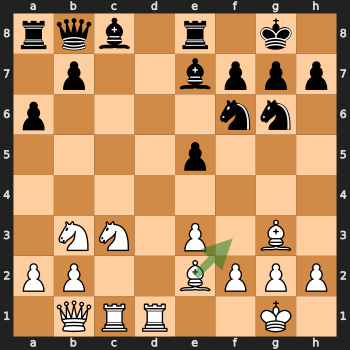

### [0] Position 1798 — **Rubinstein – Maroczy**
**White plays Bf3** (good , wp_loss=2.2%)

`rqb1r1k1/1p2bppp/p4nn1/4p3/8/1NN1P1B1/PP2BPPP/1QRR2K1 w - - 4 18`

**Engine:**
1. **h4** (+1.78): h4 h6 Ne4 Ng4 h5 Nf8 Na5 Be6
2. **Bf3** (+1.52): Bf3 a5 h4 h5 Nd2 Be6 Nde4 Rc8 <- played
3. **h3** (+1.32): h3 Rd8 Rxd8+ Bxd8 Bf3 Qd6 Rd1 Qc7

**Gold atoms:**
- Bf3 places the bishop on the long diagonal h1-a8.
- Bf3 prevents 18...b5 because after 18...b5 19.Bxa8, White wins the rook on a8.
- By preventing 18...b5, Bf3 also prevents Black from fianchettoing the bishop on b7.

{'position_number': 1798,
 'fen': 'rqb1r1k1/1p2bppp/p4nn1/4p3/8/1NN1P1B1/PP2BPPP/1QRR2K1 w - - 4 18',
 'move_uci': 'e2f3',
 'move_san': 'Bf3',
 'annotation': 'The bishop seizes the long diagonal and prevents Black from playing 18... b5 (the punishment being 19 Bxa8) and then fianchettoing his bishop.',
 'wp_loss': 2.19,
 'quality': 'good',
 'game': 'Rubinstein – Maroczy',
 'engine_lines': [{'move_uci': 'h2h4',
   'move_san': 'h4',
   'eval': '+1.78',
   'pv_san': 'h4 h6 Ne4 Ng4 h5 Nf8 Na5 Be6',
   'cp': 178,
   'mate': None,
   'is_top': True},
  {'move_uci': 'e2f3',
   'move_san': 'Bf3',
   'eval': '+1.52',
   'pv_san': 'Bf3 a5 h4 h5 Nd2 Be6 Nde4 Rc8',
   'cp': 152,
   'mate': None,
   'is_top': True},
  {'move_uci': 'h2h3',
   'move_san': 'h3',
   'eval': '+1.32',
   'pv_san': 'h3 Rd8 Rxd8+ Bxd8 Bf3 Qd6 Rd1 Qc7',
   'cp': 132,
   'mate': None,
   'is_top': True}],
 'extracted': {'include': True,
  'quality': 'good',
  'reasoning': ['Bf3 places the bishop on the long diagonal h1-a8.',

In [97]:
IDX = 0  # Change this to test different positions
show_position(IDX)

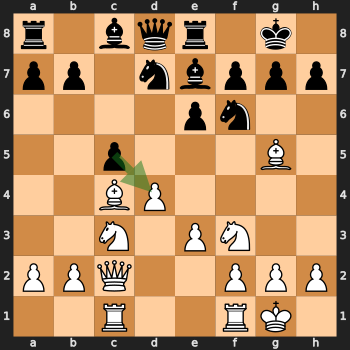

### [1] Position 1783 — **Rubinstein – Maroczy**
**Black plays cxd4** (good , wp_loss=0.0%)

`r1bqr1k1/pp1nbppp/4pn2/2p3B1/2BP4/2N1PN2/PPQ2PPP/2R2RK1 b - - 1 10`

**Engine:**
1. **cxd4** (+0.52): cxd4 Nxd4 Qb6 Be2 Nf8 Rfd1 Bd7 Qb3 <- played
2. **h6** (+1.04): h6 Bf4 a6 dxc5 Bxc5 Rfd1 Qe7 Bf1
3. **a6** (+1.16): a6 dxc5 Nxc5 Rfd1 Qa5 a3 b5 Bxf6

**Gold atoms:**
- cxd4 forces White to decide how to recapture in the center.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> cxd4 captures the pawn on d4, opening the c-file for Black's rook and potentially creating a passed pawn on the d-file. However, this move allows White to recapture with the knight on d4, centralizing the knight and increasing its activity. A more strategic option for Black could have been to play b6, preparing to develop the bishop to b7, where it would exert pressure on the e4-pawn and support the d5 advance.

#### Chernev
> Black’s intention is to force White to a decision regarding the centre. If White recaptures with a pawn, it saddles him with an isolated pawn in the middle of the board; if with a piece, then his pawn-centre is no better than Black’s.

#### Gold atoms
- cxd4 forces White to decide how to recapture in the center.

In [101]:
gen_text, gen_log = test_gen(IDX, engine=False)

In [102]:
judge_results = test_judge(IDX, gen_text)

  Decomposing into claims and atoms...
  -> 3 claims, 9 atoms
  Extracting alternative moves...
  -> 1 alternative(s) found:
     ↑ b6 (eval_diff: -7.50, 3 atoms)
  Verifying atoms (per-atom)...
  [1/9]
    Verifying: cxd4 captures the pawn on d4...
    tool: get_piece_at({'fen': 'r1bqr1k1/pp1nbppp/4pn2/2p3B1/2BP4/2N1PN2/PPQ2PPP/2R2RK1 b - - 1 10', 'square': 'd4'}) -> {"square": "d4", "piece": "white pawn"}
    tool: get_piece_at({'fen': 'r1bqr1k1/pp1nbppp/4pn2/6B1/2Bp4/2N1PN2/PPQ2PPP/2R2RK1 w - - 0 11', 'square': 'd4'}) -> {"square": "d4", "piece": "black pawn"}
  [2/9]
    Verifying: After cxd4, the c-file is opened for Black's rook...
    tool: get_piece_at({'fen': 'r1bqr1k1/pp1nbppp/4pn2/6B1/2Bp4/2N1PN2/PPQ2PPP/2R2RK1 w - - 0 11', 'square': 'c8'}) -> {"square": "c8", "piece": "black bishop"}
    tool: get_piece_at({'fen': 'r1bqr1k1/pp1nbppp/4pn2/6B1/2Bp4/2N1PN2/PPQ2PPP/2R2RK1 w - - 0 11', 'square': 'c7'}) -> {"square": "c7", "piece": "empty"}
    tool: get_piece_at({'fen': 'r1bqr1k

| Metric | Score |
|--------|-------|
| Claim Accuracy | **33%** (1/3) |
| Recall | **100%** (1/1) |
| Quality | **correct** (gen=inconclusive, actual=good) |
| Fluency | **4.16** / 5 |
| Specificity | **4.42** / 5 |
| **Composite** | **0.757** |
| Sanity overrides | 0 |


**Alternative moves mentioned:**

- **b6** ↑ BETTER ⚠️ **CLAIMED BETTER (actually -7.5 worse)** | eval: +1.36 | WP: played: 54.8% → alt: 62.3% (diff: -7.5) | 3 atoms — variation: b6 Bb7

**Claims:**

...

- [Y] `[piece_placement]` (high) Playing b6 prepares to develop the bishop to b7  
  **ALT CONTEXT (b6):** ✓ The move b6 opens the diagonal for the black bishop on c8 to move to b7. The squares b7 and c8 are aligned diagonally, allowing the bishop to be developed to b7 after the pawn move b6.

- [N] `[move_sequence]` (low) After b6 Bb7, the bishop would exert pressure on the e4-pawn  
  **ALT CONTEXT (b6):** ✗ The move Bb7 is illegal in the given position. Therefore, the claim that the bishop would exert pressure on the e4-pawn after Bb7 is invalid.

- [N] `[move_sequence]` (high) After b6 Bb7, the bishop would support the d5 advance  
  **ALT CONTEXT (b6):** ✗ The move Bb7 is illegal in the given position because there is no piece on b7 after Black's move b6. Therefore, the claim that the bishop on b7 would support the d5 advance is invalid.

**Gold atoms (covered):**

- [Y] cxd4 forces White to decide how to recapture in the center.  
  *matched: After cxd4, White can recapture with the knight on d4*

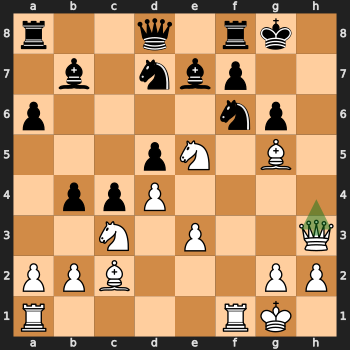

### [2] Position 958 — **Pillsbury – Marco**
**White plays Qh4** (good , wp_loss=0.4%)

`r2q1rk1/1b1nbp2/p4np1/3pN1B1/1ppP4/2N1P2Q/PPB3PP/R4RK1 w - - 0 17`

**Engine:**
1. **Nxg6** (+4.01): Nxg6 fxg6 Bxg6 Rf7 Bxf7+ Kxf7 Qh7+ Ke6
2. **Qh4** (+3.94): Qh4 bxc3 bxc3 Nxe5 dxe5 Ne4 Bxe7 g5 <- played
3. **Nxd7** (+3.03): Nxd7 Qxd7 Qxd7 Nxd7 Bxe7 bxc3 Bxf8 cxb2

**Gold atoms:**
- Qh4 increases the pressure on the knight on f6.
- The knight on f6 has been weakened because it has lost its pawn support.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> Qh4 is a blunder because it allows Black to capture the knight on e5 with Nxe5, gaining a piece and attacking the queen simultaneously. Instead, White should have played Nxd7, removing one of the defenders of the f6-knight and preparing to capture it, which would have also disrupted Black's coordination.

...

- [Y] `[comparison, material, piece_placement]` (high) If White plays Nxd7 instead, it prepares to capture the knight on f6  
  *After the move Nxd7, the resulting position shows that the white knight on d7 is indeed attacking the knight on f6. The tool results confirm that the knight on d7 is one of the attackers of the f6 square, along with the bishop on g5 and the rook on f1. Therefore, the claim that playing Nxd7 prepares to capture the knight on f6 is accurate.*

- [N] `[move_sequence]` (high) After Nxd7 Nxf6, Black's coordination would be disrupted  
  *The move sequence 'Nxd7 Nxf6' is illegal from the given post-move FEN position. The move 'Nxd7' is not a legal move for Black in this position, as verified by the list of legal moves. Therefore, the claim cannot be verified as it is based on an illegal sequence.*

**Gold atoms (covered):**

- [N] Qh4 increases the pressure on the knight on f6.

- [N] The knight on f6 has been weakened because it has lost its pawn support.

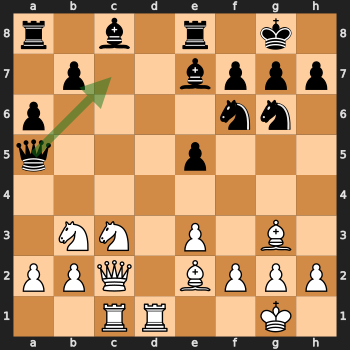

### [3] Position 1795 — **Rubinstein – Maroczy**
**Black plays Qc7** (good , wp_loss=0.3%)

`r1b1r1k1/1p2bppp/p4nn1/q3p3/8/1NN1P1B1/PPQ1BPPP/2RR2K1 b - - 1 16`

**Engine:**
1. **Qb6** (+1.06): Qb6 h4 h5 Bd3 Bg4 Rd2 a5 Na4
2. **Qc7** (+1.09): Qc7 h4 h5 Qb1 Qb6 Nd2 Rd8 Nc4 <- played
3. **Qb4** (+1.10): Qb4 a3 Qb6 Nd2 Be6 h4 h5 Bd3

**Gold atoms:**
- Qc7 moves the queen away from attack.
- After Qc7, Black prepares to regroup by ...Bd7, ...Bc6, and ...Rad8.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> Qc7 retreats the queen to a safer square while maintaining pressure on the c-file and supporting the knight on f6. However, this move is passive and misses an opportunity to activate Black's pieces. A more dynamic option would be Bb4, pinning the knight on c3 and increasing pressure on the pinned piece, potentially preparing for tactical opportunities like Bxc3 or even Bxc3 followed by Ne4, targeting the pinned knight and centralizing Black's pieces.

...

- [N] `[move_sequence, piece_placement]` (high) After Bb4 Bxc3 Ne4, Black targets the pinned knight on c3  
  *The move sequence 'Bb4 Bxc3 Ne4' is illegal from the given post-move position FEN 'r1b1r1k1/1pq1bppp/p4nn1/4p3/8/1NN1P1B1/PPQ1BPPP/2RR2K1 w - - 2 17'. The move 'Bb4' is not a legal move for White in this position. Therefore, the claim cannot be verified as the sequence cannot occur.*

- [N] `[move_sequence]` (low) After Bb4 Bxc3 Ne4, Black centralizes its pieces  
  *The move sequence "Bb4 Bxc3 Ne4" is not legal from the given post-move FEN position. The move "Bb4" is not a legal move for White in this position. Therefore, the claim cannot be verified as the sequence cannot be executed.

{"verified": false, "confidence": "high", "reasoning": "The move sequence 'Bb4 Bxc3 Ne4' is illegal from the given position, making it impossible to verify the claim about Black centralizing its pieces after these moves."}*

**Gold atoms (covered):**

- [Y] Qc7 moves the queen away from attack.  
  *matched: Qc7 retreats the queen to a safer square*

- [N] After Qc7, Black prepares to regroup by ...Bd7, ...Bc6, and ...Rad8.

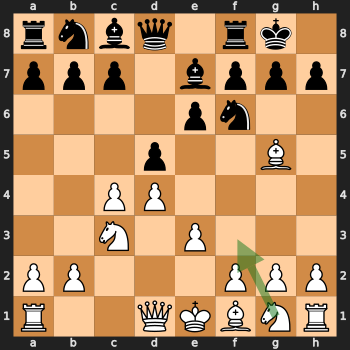

### [4] Position 936 — **Pillsbury – Marco**
**White plays Nf3** (good , wp_loss=0.0%)

`rnbq1rk1/ppp1bppp/4pn2/3p2B1/2PP4/2N1P3/PP3PPP/R2QKBNR w KQ - 1 6`

**Engine:**
1. **Nf3** (+0.20): Nf3 Nbd7 Qc2 c5 cxd5 Nxd5 Bxe7 Qxe7 <- played
2. **Qc2** (+0.19): Qc2 c5 dxc5 h6 Bh4 Na6 Nf3 Nxc5
3. **Rc1** (+0.07): Rc1 c5 dxc5 dxc4 Bxc4 Qxd1+ Rxd1 Nbd7

**Gold atoms:**
- Nf3 develops the knight and leaves White's two knights exerting pressure on all four central squares.
- After Nf3, the knight on f3 eyes e5 as an outpost.


Generating (openai/gpt-4o, raw prompt)...


#### Generated
> Nf3 develops the knight to a natural square, supporting the d4 pawn and preparing to castle kingside. This move also opens lines for the queen's rook and enhances control over the e5 square, which is crucial for maintaining central tension.

...

- [Y] `[positional]` (high) Nf3 enhances control over the e5 square  
  *Before the move Nf3, the e5 square was attacked by 1 white piece (the pawn on d4). After the move Nf3, the e5 square is attacked by 2 white pieces (the knight on f3 and the pawn on d4). Therefore, Nf3 enhances control over the e5 square by adding an additional attacker.*

- [Y] `[positional]` (medium) Control over the e5 square is crucial for maintaining central tension  
  *The e5 square is currently attacked by two White pieces (a knight on f3 and a pawn on d4) and not defended by any Black pieces. This indicates that White has control over the e5 square. The engine evaluation of the position is +0.21, suggesting a slight advantage for White, which implies that maintaining control over central squares like e5 contributes to this advantage. Therefore, control over the e5 square is indeed crucial for maintaining central tension, as it allows White to exert influence in the center and potentially restrict Black's options.*

**Gold atoms (covered):**

- [Y] Nf3 develops the knight and leaves White's two knights exerting pressure on all four central squares.  
  *matched: Nf3 develops the knight to a natural square*

- [Y] After Nf3, the knight on f3 eyes e5 as an outpost.  
  *matched: Nf3 enhances control over the e5 square*

In [104]:
for IDX in range(2, 5):
    gen_text, gen_log = test_gen(IDX, engine=False)
    judge_results = test_judge(IDX, gen_text)

---
## Demo: Batch Evaluation

In [ ]:
# Run batch evaluation on 5 random positions
# batch_results = batch_evaluate(n=5, seed=42)
# df = summarize_results(batch_results)

In [ ]:
# Compare models
# results_gpt = batch_evaluate(n=5, seed=42, gen_model='gpt-4o')
# results_claude = batch_evaluate(n=5, seed=42, provider='anthropic', gen_model='claude-sonnet-4-5-20250929')